In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator
from scipy.stats import skewnorm
import ot
import ot.plot


warnings.filterwarnings("ignore", message="The number of replications is low")

# One dimension

In [ ]:
rng = np.random.default_rng(0)

n = 10


def standardized_skewnorm(alpha, size, rng):
    delta = alpha / np.sqrt(1 + alpha**2)
    omega = 1 / np.sqrt(1 - 2 * delta**2 / np.pi)   # scale that fixes variance = 1
    xi = -omega * delta * np.sqrt(2 / np.pi)          # location that fixes mean = 0
    return skewnorm.rvs(alpha, loc=xi, scale=omega, size=size, random_state=rng)


# different mean, same variance
x_1 = rng.normal(loc=0.0, scale=1.0, size=n)
y_1 = rng.normal(loc=4.0, scale=1.0, size=n)

# same mean, different variance
x_2 = rng.normal(loc=0.0, scale=1.0, size=n)
y_2 = rng.normal(loc=0.0, scale=9.0, size=n)

# same mean (0) AND same variance (1), but different third moment: x_3 is
# standard normal (skewness 0), y_3 is a standardized skew-normal (skewness > 0)
x_3 = rng.normal(loc=0.0, scale=1.0, size=n)
y_3 = standardized_skewnorm(8.0, n, rng)

In [3]:
# sort so that index i in the cost matrix / transport plan corresponds to the i-th
# order statistic x_(i), y_(i), not the i-th randomly-generated point -- otherwise
# the matched-pairs structure gets scrambled across the matrix purely by array
# order, even though the underlying optimal coupling is the clean sorted-to-sorted
# monotone matching (see the very first derivation in this notebook's sibling)
x_1 = np.sort(x_1)
y_1 = np.sort(y_1)

# OT matrix
G0 = ot.emd_1d(x_1, y_1) #squared Euclidean distance

# optimal 1D coupling: which source point is matched to which target point
rows, cols = np.nonzero(G0)  # matched (source, target) index pairs

# Cost Matrix
M = ot.dist(x_1.reshape(-1, 1), y_1.reshape(-1, 1))

print(ot.emd2_1d(x_1, y_1)**(1/2))  # optimal transport cost

# same again for x_2, y_2 (same mean, different variance)
x_2 = np.sort(x_2)
y_2 = np.sort(y_2)

G0_2 = ot.emd_1d(x_2, y_2)
rows_2, cols_2 = np.nonzero(G0_2)
M_2 = ot.dist(x_2.reshape(-1, 1), y_2.reshape(-1, 1))

print(ot.emd2_1d(x_2, y_2)**(1/2))  # optimal transport cost

# same again for x_3, y_3 (same mean AND variance, different third moment)
x_3 = np.sort(x_3)
y_3 = np.sort(y_3)

G0_3 = ot.emd_1d(x_3, y_3)
rows_3, cols_3 = np.nonzero(G0_3)
M_3 = ot.dist(x_3.reshape(-1, 1), y_3.reshape(-1, 1))

print(ot.emd2_1d(x_3, y_3)**(1/2))  # optimal transport cost

3.4714113929638626
5.593654281584539
1.0703189706406748


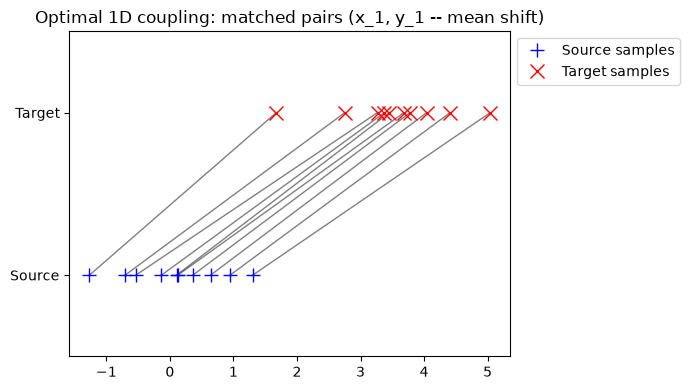

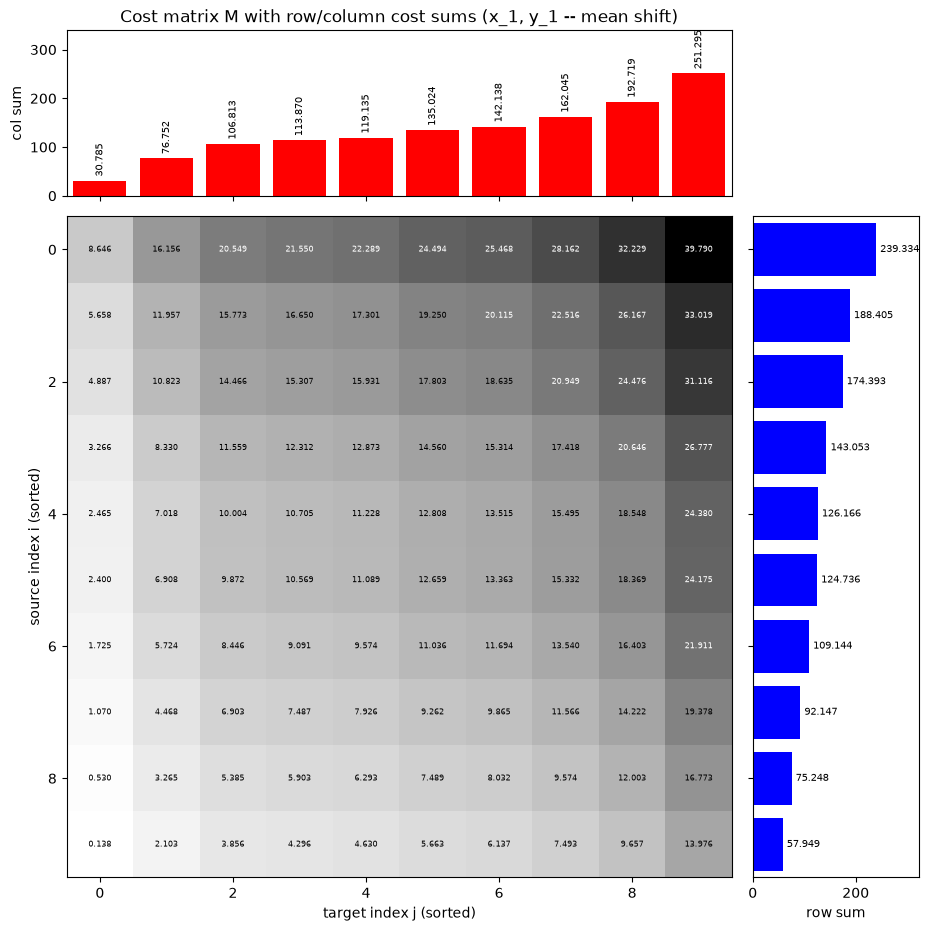

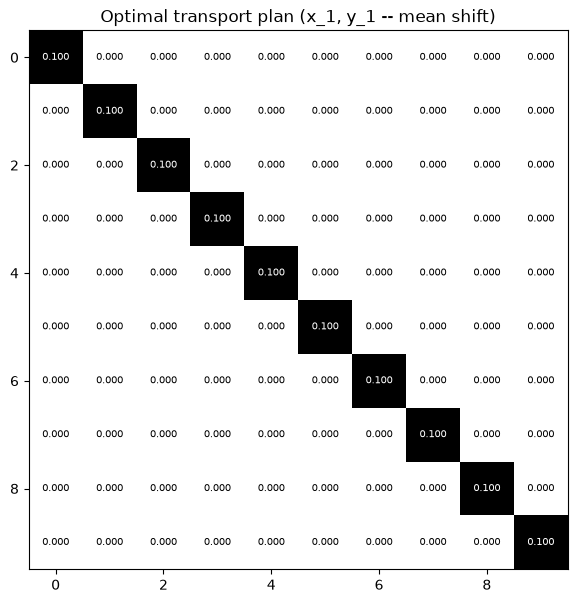

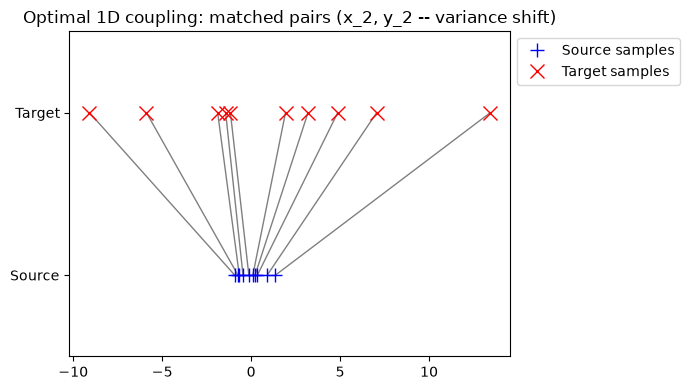

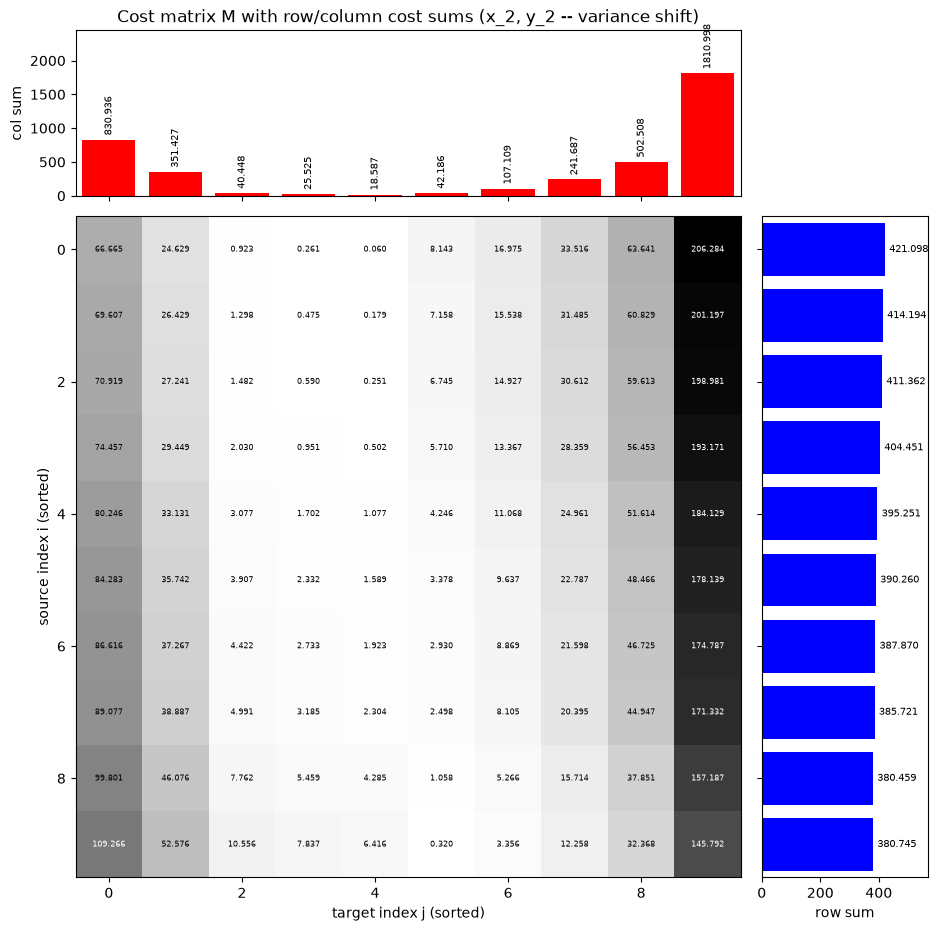

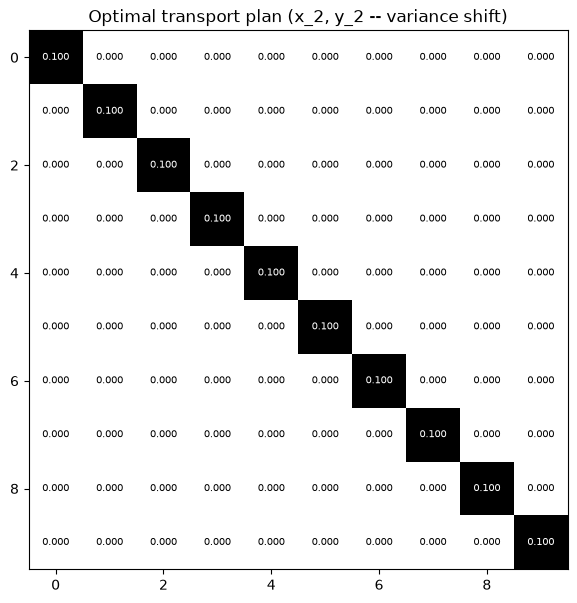

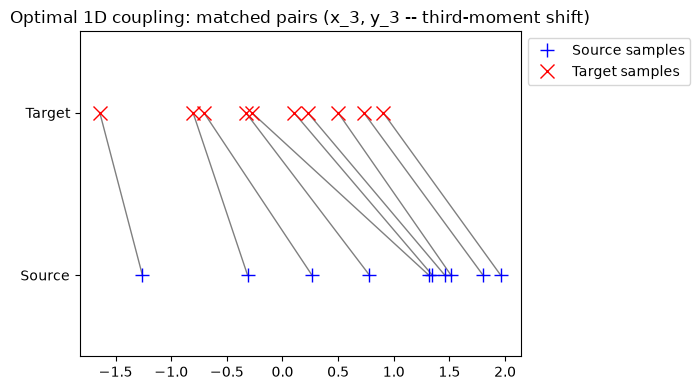

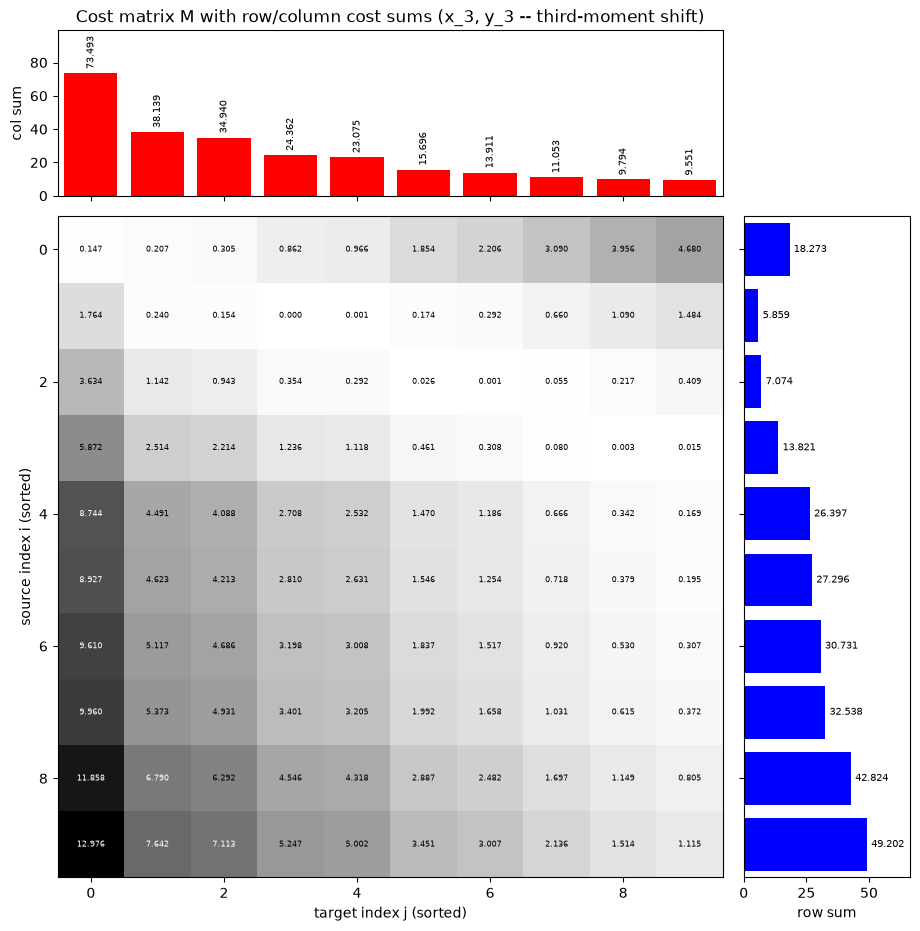

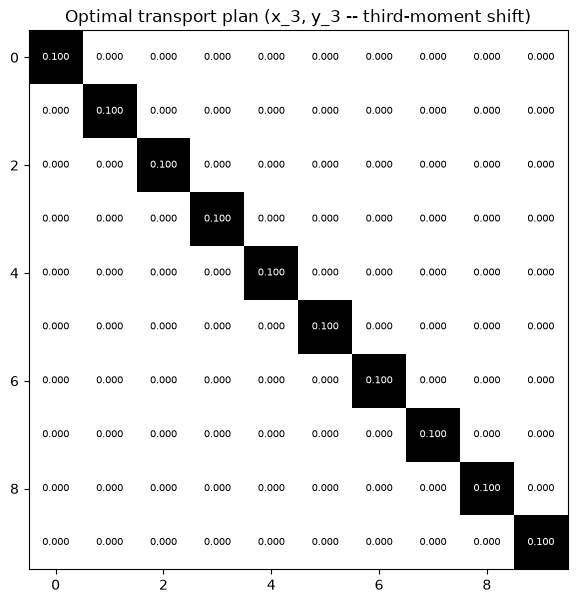

In [4]:
pl.figure(1, figsize=(7, 4))
y_source, y_target = 0, 1
for i, j in zip(rows, cols):
    pl.plot([x_1[i], y_1[j]], [y_source, y_target], "k-", alpha=0.5, lw=1, zorder=1)
pl.plot(x_1, np.full_like(x_1, y_source), "+b", label="Source samples", markersize=10, zorder=2)
pl.plot(y_1, np.full_like(y_1, y_target), "xr", label="Target samples", markersize=10, zorder=2)
pl.yticks([y_source, y_target], ["Source", "Target"])
pl.ylim(-0.5, 1.5)
pl.legend(loc="upper left", bbox_to_anchor=(1, 1))
pl.title("Optimal 1D coupling: matched pairs (x_1, y_1 -- mean shift)")
pl.tight_layout()

# Cost matrix M -- exactly the same annotated version as the "most influential points"
# cell below: full heatmap with individual cost values per cell, plus row/column cost
# sums as marginal bar charts with exact numeric labels.
row_sums = M.sum(axis=1)
col_sums = M.sum(axis=0)

fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j (sorted)")
ax_main.set_ylabel("source index i (sorted)")

vmid = (M.max() + M.min()) / 2
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        color = "white" if M[i, j] > vmid else "black"
        ax_main.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums)), col_sums, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M with row/column cost sums (x_1, y_1 -- mean shift)")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums)), row_sums, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

# Optimal transport plan G0 -- annotate each cell with the exact mass transported
# (most cells are exactly 0; the sparse nonzero entries are the actual matches)
pl.figure(3, figsize=(7, 7))
pl.imshow(G0, interpolation="nearest", cmap="gray_r")
pl.title("Optimal transport plan (x_1, y_1 -- mean shift)")
vmid_g0 = (G0.max() + G0.min()) / 2
for i in range(G0.shape[0]):
    for j in range(G0.shape[1]):
        color = "white" if G0[i, j] > vmid_g0 else "black"
        pl.text(j, i, f"{G0[i, j]:.3f}", ha="center", va="center", color=color, fontsize=7)

# same three plots again for x_2, y_2 (same mean, different variance) -- no code
# changes beyond swapping in the _2 variables, since none of this logic is
# specific to the mean-shift scenario
pl.figure(4, figsize=(7, 4))
for i, j in zip(rows_2, cols_2):
    pl.plot([x_2[i], y_2[j]], [y_source, y_target], "k-", alpha=0.5, lw=1, zorder=1)
pl.plot(x_2, np.full_like(x_2, y_source), "+b", label="Source samples", markersize=10, zorder=2)
pl.plot(y_2, np.full_like(y_2, y_target), "xr", label="Target samples", markersize=10, zorder=2)
pl.yticks([y_source, y_target], ["Source", "Target"])
pl.ylim(-0.5, 1.5)
pl.legend(loc="upper left", bbox_to_anchor=(1, 1))
pl.title("Optimal 1D coupling: matched pairs (x_2, y_2 -- variance shift)")
pl.tight_layout()

row_sums_2 = M_2.sum(axis=1)
col_sums_2 = M_2.sum(axis=0)

fig2 = pl.figure(figsize=(11, 11))
gs2 = fig2.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main2 = fig2.add_subplot(gs2[1, 0])
ax_top2 = fig2.add_subplot(gs2[0, 0], sharex=ax_main2)
ax_right2 = fig2.add_subplot(gs2[1, 1], sharey=ax_main2)

ax_main2.imshow(M_2, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main2.set_xlabel("target index j (sorted)")
ax_main2.set_ylabel("source index i (sorted)")

vmid2 = (M_2.max() + M_2.min()) / 2
for i in range(M_2.shape[0]):
    for j in range(M_2.shape[1]):
        color = "white" if M_2[i, j] > vmid2 else "black"
        ax_main2.text(j, i, f"{M_2[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top2 = ax_top2.bar(np.arange(len(col_sums_2)), col_sums_2, color="red")
ax_top2.bar_label(bars_top2, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top2.set_title("Cost matrix M with row/column cost sums (x_2, y_2 -- variance shift)")
ax_top2.tick_params(labelbottom=False)
ax_top2.set_ylabel("col sum")
ax_top2.margins(y=0.35)

bars_right2 = ax_right2.barh(np.arange(len(row_sums_2)), row_sums_2, color="blue")
ax_right2.bar_label(bars_right2, fmt="%.3f", fontsize=7, padding=3)
ax_right2.tick_params(labelleft=False)
ax_right2.set_xlabel("row sum")
ax_right2.margins(x=0.35)
pl.show()

pl.figure(6, figsize=(7, 7))
pl.imshow(G0_2, interpolation="nearest", cmap="gray_r")
pl.title("Optimal transport plan (x_2, y_2 -- variance shift)")
vmid_g0_2 = (G0_2.max() + G0_2.min()) / 2
for i in range(G0_2.shape[0]):
    for j in range(G0_2.shape[1]):
        color = "white" if G0_2[i, j] > vmid_g0_2 else "black"
        pl.text(j, i, f"{G0_2[i, j]:.3f}", ha="center", va="center", color=color, fontsize=7)

# same three plots again for x_3, y_3 (same mean AND variance, different third
# moment: y_3 is a standardized skew-normal) -- once more only the variables change
pl.figure(7, figsize=(7, 4))
for i, j in zip(rows_3, cols_3):
    pl.plot([x_3[i], y_3[j]], [y_source, y_target], "k-", alpha=0.5, lw=1, zorder=1)
pl.plot(x_3, np.full_like(x_3, y_source), "+b", label="Source samples", markersize=10, zorder=2)
pl.plot(y_3, np.full_like(y_3, y_target), "xr", label="Target samples", markersize=10, zorder=2)
pl.yticks([y_source, y_target], ["Source", "Target"])
pl.ylim(-0.5, 1.5)
pl.legend(loc="upper left", bbox_to_anchor=(1, 1))
pl.title("Optimal 1D coupling: matched pairs (x_3, y_3 -- third-moment shift)")
pl.tight_layout()

row_sums_3 = M_3.sum(axis=1)
col_sums_3 = M_3.sum(axis=0)

fig3 = pl.figure(figsize=(11, 11))
gs3 = fig3.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main3 = fig3.add_subplot(gs3[1, 0])
ax_top3 = fig3.add_subplot(gs3[0, 0], sharex=ax_main3)
ax_right3 = fig3.add_subplot(gs3[1, 1], sharey=ax_main3)

ax_main3.imshow(M_3, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main3.set_xlabel("target index j (sorted)")
ax_main3.set_ylabel("source index i (sorted)")

vmid3 = (M_3.max() + M_3.min()) / 2
for i in range(M_3.shape[0]):
    for j in range(M_3.shape[1]):
        color = "white" if M_3[i, j] > vmid3 else "black"
        ax_main3.text(j, i, f"{M_3[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top3 = ax_top3.bar(np.arange(len(col_sums_3)), col_sums_3, color="red")
ax_top3.bar_label(bars_top3, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top3.set_title("Cost matrix M with row/column cost sums (x_3, y_3 -- third-moment shift)")
ax_top3.tick_params(labelbottom=False)
ax_top3.set_ylabel("col sum")
ax_top3.margins(y=0.35)

bars_right3 = ax_right3.barh(np.arange(len(row_sums_3)), row_sums_3, color="blue")
ax_right3.bar_label(bars_right3, fmt="%.3f", fontsize=7, padding=3)
ax_right3.tick_params(labelleft=False)
ax_right3.set_xlabel("row sum")
ax_right3.margins(x=0.35)
pl.show()

pl.figure(9, figsize=(7, 7))
pl.imshow(G0_3, interpolation="nearest", cmap="gray_r")
pl.title("Optimal transport plan (x_3, y_3 -- third-moment shift)")
vmid_g0_3 = (G0_3.max() + G0_3.min()) / 2
for i in range(G0_3.shape[0]):
    for j in range(G0_3.shape[1]):
        color = "white" if G0_3[i, j] > vmid_g0_3 else "black"
        pl.text(j, i, f"{G0_3[i, j]:.3f}", ha="center", va="center", color=color, fontsize=7)

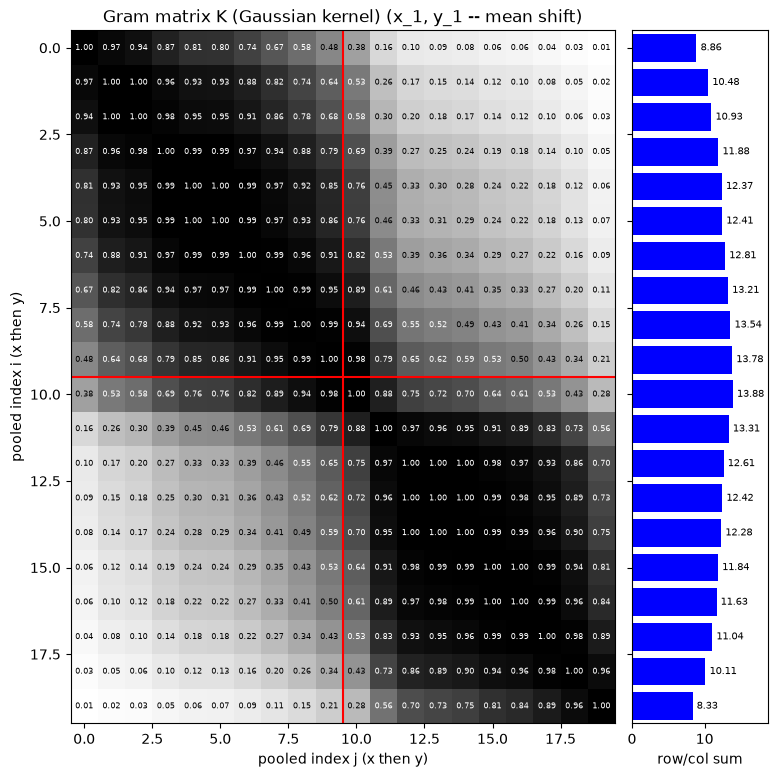

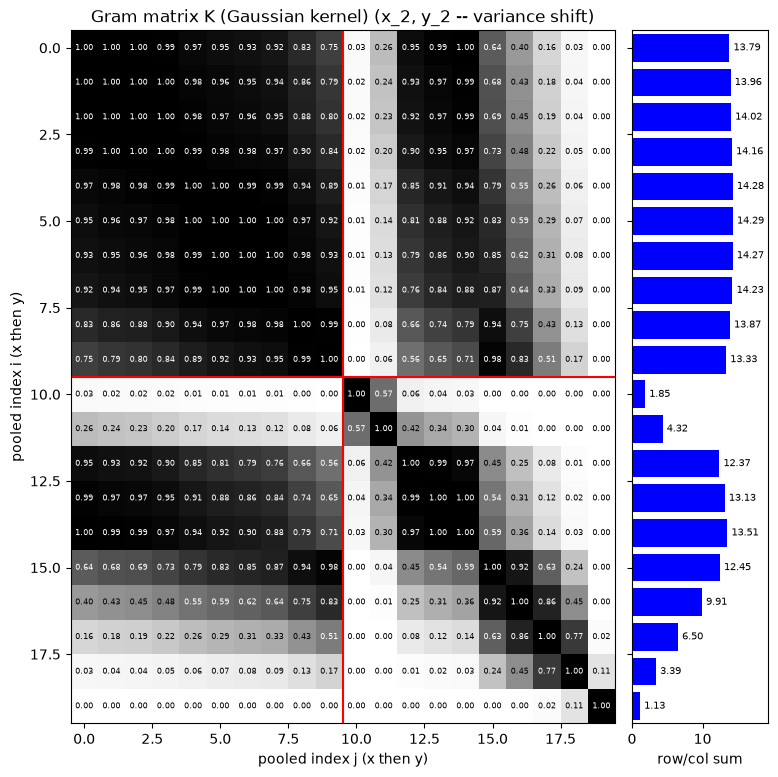

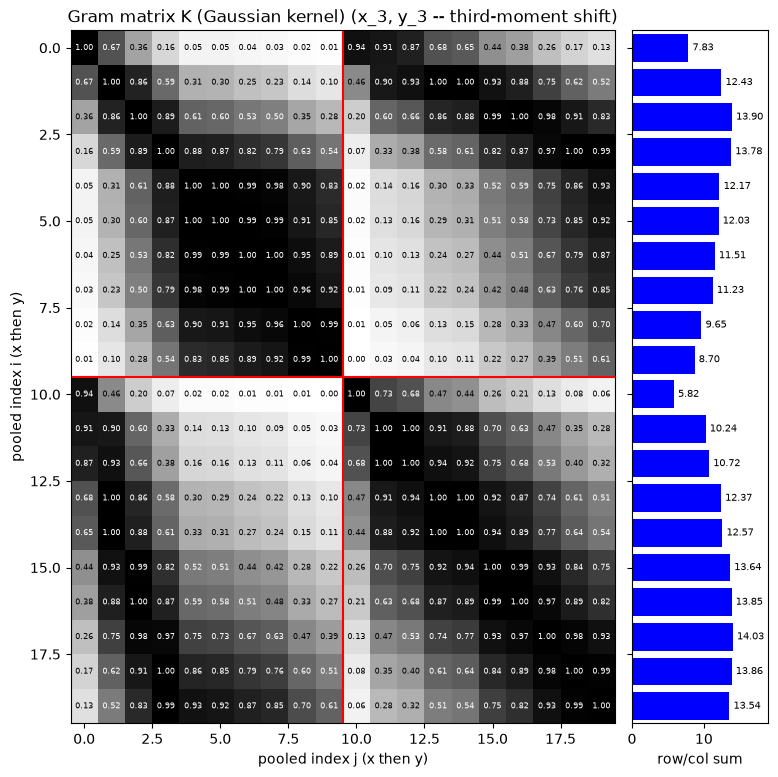

In [ ]:
def plot_gram_matrix(x, y, label=""):
    n = len(x)
    z = np.concatenate([x, y]).reshape(-1, 1)
    sq_dists = (z - z.T) ** 2
    off_diag = np.sqrt(sq_dists)[~np.eye(len(z), dtype=bool)]
    sigma = np.median(off_diag)
    K = np.exp(-sq_dists / (2 * sigma ** 2))

    row_sums = K.sum(axis=1)

    fig = pl.figure(figsize=(9, 9))
    gs = fig.add_gridspec(1, 2, width_ratios=(4, 1), wspace=0.05)
    ax_main = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1], sharey=ax_main)

    ax_main.imshow(K, interpolation="nearest", cmap="gray_r", aspect="auto")
    ax_main.axhline(n - 0.5, color="red", lw=1.5)
    ax_main.axvline(n - 0.5, color="red", lw=1.5)
    ax_main.set_xlabel("pooled index j (x then y)")
    ax_main.set_ylabel("pooled index i (x then y)")
    ax_main.set_title(f"Gram matrix K (Gaussian kernel) {label}")

    vmid = (K.max() + K.min()) / 2
    for i in range(K.shape[0]):
        for j in range(K.shape[1]):
            color = "white" if K[i, j] > vmid else "black"
            ax_main.text(j, i, f"{K[i, j]:.2f}", ha="center", va="center", color=color, fontsize=6)

    bars_right = ax_right.barh(np.arange(len(row_sums)), row_sums, color="blue")
    ax_right.bar_label(bars_right, fmt="%.2f", fontsize=7, padding=3)
    ax_right.tick_params(labelleft=False)
    ax_right.set_xlabel("row/col sum")
    ax_right.margins(x=0.35)
    pl.show()


plot_gram_matrix(x_1, y_1, label="(x_1, y_1 -- mean shift)")
plot_gram_matrix(x_2, y_2, label="(x_2, y_2 -- variance shift)")
plot_gram_matrix(x_3, y_3, label="(x_3, y_3 -- third-moment shift)")

In [ ]:
deltas = np.linspace(0, 0.3, 7)
stds = np.linspace(1, 1.5, 6)
# skew-normal shape parameter alpha for the third-moment scenarios. 

skews = np.linspace(0, 8, 6)

In [ ]:
from scipy.stats import permutation_test


def wasserstein_permutation_pvalue(x, y, n_perm=200, rng=None):
    """Works for samples of ANY dimension: x, y should be shape (n,) or (n, d)."""
    if rng is None:
        rng = np.random.default_rng()

    x = np.asarray(x, dtype=float).reshape(len(x), -1)
    y = np.asarray(y, dtype=float).reshape(len(y), -1)
    if x.shape[1] == 1 and len(x) == len(y):
        def w2_stat(x, y, axis):
            if x.ndim == 2:  # single (observed-statistic) call: shape (d, n) = (1, n)
                return np.float64(np.sqrt(np.mean((np.sort(x[0]) - np.sort(y[0])) ** 2)))
            xs = np.sort(x[:, 0, :], axis=-1)  # (B, n)
            ys = np.sort(y[:, 0, :], axis=-1)
            return np.sqrt(np.mean((xs - ys) ** 2, axis=-1))  # (B,)
    else:
        def w2_stat(x, y, axis):
            def solve_one(xi, yi):
                xi, yi = xi.T, yi.T  # (d, n) -> (n, d)
                n, m = len(xi), len(yi)
                a, b = np.ones(n) / n, np.ones(m) / m
                M = ot.dist(xi, yi)
                return ot.emd2(a, b, M) ** 0.5

            if x.ndim == 2:  # single (observed-statistic) call: shape (d, n)
                return np.float64(solve_one(x, y))
            return np.array([solve_one(xb, yb) for xb, yb in zip(x, y)])  # (B, d, n)

    result = permutation_test(
        (x, y),
        w2_stat,
        vectorized=True,
        permutation_type="independent",
        axis=0,
        n_resamples=n_perm,
        alternative="greater",
        random_state=rng,
    )
    return result.pvalue


# quick check: one p-value at our dataset
print(wasserstein_permutation_pvalue(x_1, y_1, n_perm=200, rng=rng))
print(wasserstein_permutation_pvalue(x_2, y_2, n_perm=200, rng=rng))

0.009950248756218905
0.014925373134328358


In [ ]:
from hyppo.ksample import Hotelling


def hotelling_statistic(x, y):
    x = np.asarray(x, dtype=float).reshape(len(x), -1)
    y = np.asarray(y, dtype=float).reshape(len(y), -1)
    n, m, p = len(x), len(y), x.shape[1]
    stat = Hotelling().statistic(x, y)
    if p > 1:
        return stat
    Sx = np.cov(x, rowvar=False)
    Sy = np.cov(y, rowvar=False)
    S_pooled = ((n - 1) * Sx + (m - 1) * Sy) / (n + m - 2)
    return float(np.squeeze(stat) / S_pooled)


def hotelling_pvalue(x, y, n_perm=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float).reshape(len(x), -1)
    y = np.asarray(y, dtype=float).reshape(len(y), -1)
    n = len(x)
    pooled = np.vstack([x, y])
    obs = hotelling_statistic(x, y)
    count = 1
    for _ in range(n_perm):
        idx = rng.permutation(len(pooled))
        if hotelling_statistic(pooled[idx[:n]], pooled[idx[n:]]) >= obs:
            count += 1
    return count / (n_perm + 1)


# quick check on the two illustrative 1D datasets (mean shift, variance shift)
print(hotelling_pvalue(x_1, y_1, rng=rng))
print(hotelling_pvalue(x_2, y_2, rng=rng))

0.004975124378109453
0.6069651741293532


In [9]:
from hyppo.ksample import MMD

print(MMD(compute_kernel="gaussian").test(x_1, y_1, reps=1000, workers=1, auto=False, random_state=rng).pvalue)
print(MMD(compute_kernel="gaussian").test(x_2, y_2, reps=1000, workers=1, auto=False, random_state=rng).pvalue)

def mmd_pvalue(x, y, n_perm=200, rng=None):
    """Wraps MMD().test as a plain (x, y, n_perm=..., rng=...) -> pvalue callable.
    """
    _, pvalue = MMD(compute_kernel="gaussian").test(x, y, reps=n_perm, workers=1, auto=False, random_state=rng)
    return pvalue

0.000999000999000999
0.000999000999000999


In [ ]:
from joblib import Parallel, delayed


def power_curve(sample_fn, param_values, n_val, n_reps=300, n_perm=200, seed=0, title=None, pvalue_fn=None, param_label=None, n_jobs=6):
    pvalue_fn = pvalue_fn or wasserstein_permutation_pvalue
    param_label = param_label or (lambda p: f"param = {p:g}" if isinstance(p, (int, float, np.floating)) else f"param = {p}")

    pvalues = {}
    if n_jobs == 1:
        sim_rng_local = np.random.default_rng(seed)
        for param in param_values:
            pvals = np.empty(n_reps)
            for i in range(n_reps):
                Xi, Yi = sample_fn(param, n_val, sim_rng_local)
                pvals[i] = pvalue_fn(Xi, Yi, n_perm=n_perm, rng=sim_rng_local)
            pvalues[param] = pvals
    else:
        def _one_rep(child_seed, param):
            warnings.filterwarnings("ignore", message="The number of replications is low")
            r = np.random.default_rng(child_seed)
            Xi, Yi = sample_fn(param, n_val, r)
            return pvalue_fn(Xi, Yi, n_perm=n_perm, rng=r)

        param_seeds = np.random.SeedSequence(seed).spawn(len(param_values))
        for param, param_seed in zip(param_values, param_seeds):
            child_seeds = param_seed.spawn(n_reps)
            pvals = np.array(Parallel(n_jobs=n_jobs)(delayed(_one_rep)(cs, param) for cs in child_seeds))
            pvalues[param] = pvals

    fig, ax = plt.subplots(figsize=(6, 6))
    alphas = np.linspace(0, 1, 200)
    for param, pvals in pvalues.items():
        power = [np.mean(pvals <= a) for a in alphas]
        ax.plot(alphas, power, label=param_label(param))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="$y=x$ (null)")
    ax.axvline(0.05, color="red", lw=1, label=r"$\alpha = 0.05$")
    ax.set_xlabel(r"significance level $\alpha$")
    ax.set_ylabel(r"power $=P(\text{p-value} \leq \alpha)$")
    ax.set_title(title or f"Power of the $W_2$ permutation test via ECDF of p-values (n={n_val})")
    ax.legend()
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return pvalues

In [ ]:
def normal_shift_1d(delta, n_val, rng):
    rx, ry = rng.spawn(2)
    return rx.normal(0.0, 1.0, n_val), ry.normal(delta, 1.0, n_val)


def normal_scale_1d(std, n_val, rng):
    rx, ry = rng.spawn(2)
    return rx.normal(0.0, 1.0, n_val), ry.normal(0.0, std, n_val)


def skew_shift_1d(alpha, n_val, rng):
    rx, ry = rng.spawn(2)
    X = rx.normal(0.0, 1.0, n_val)
    Y = standardized_skewnorm(alpha, n_val, ry)
    return X, Y

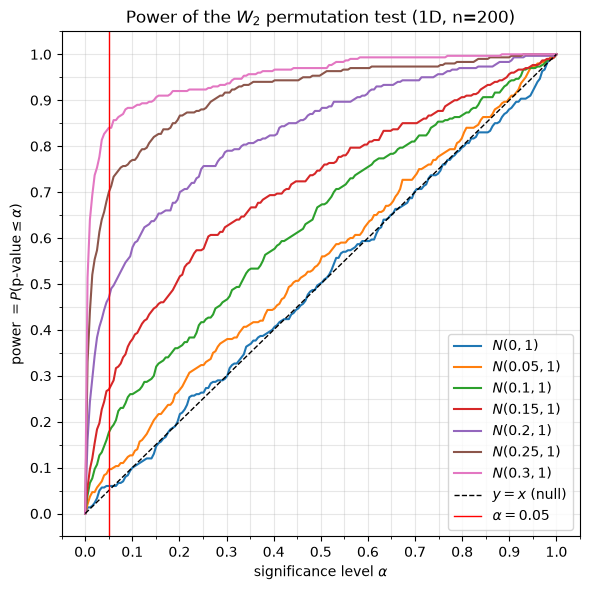

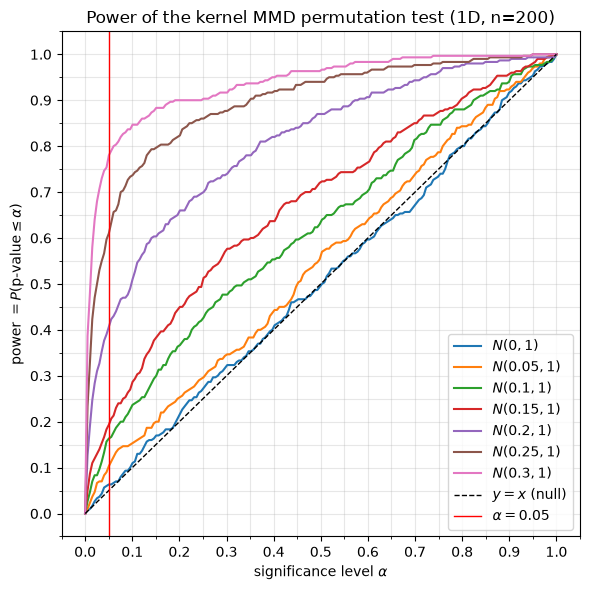

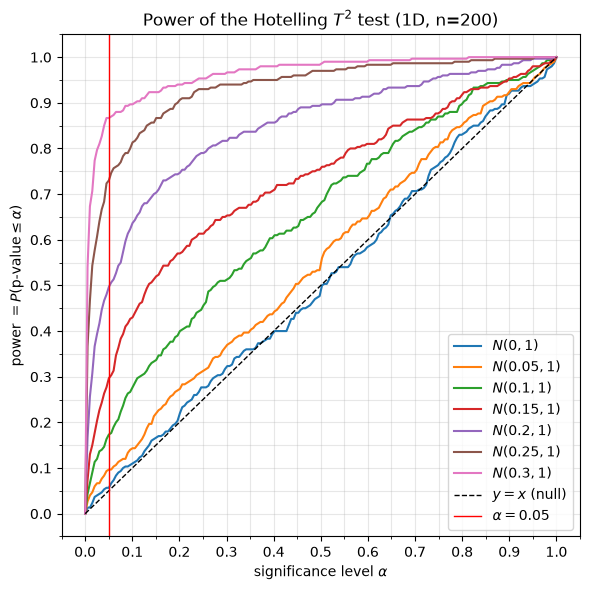

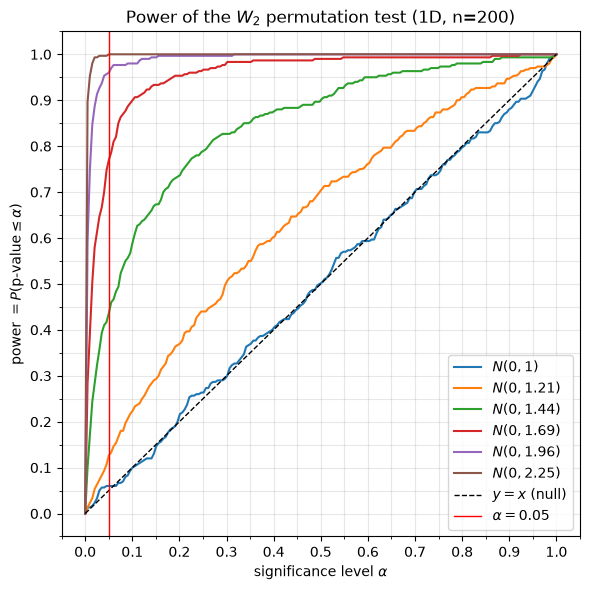

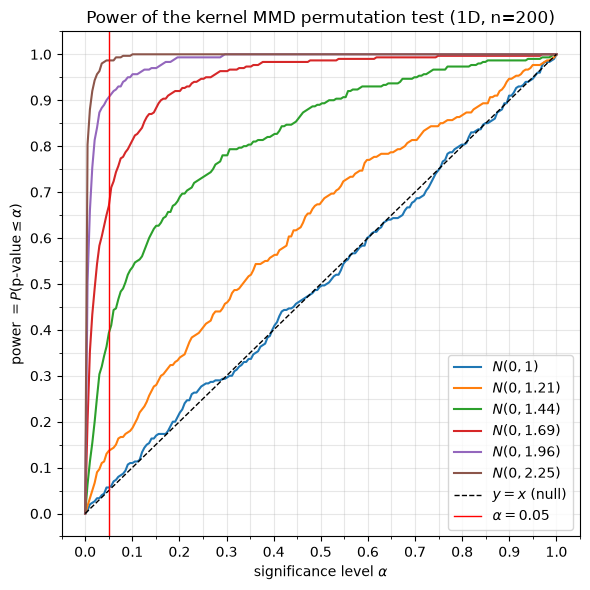

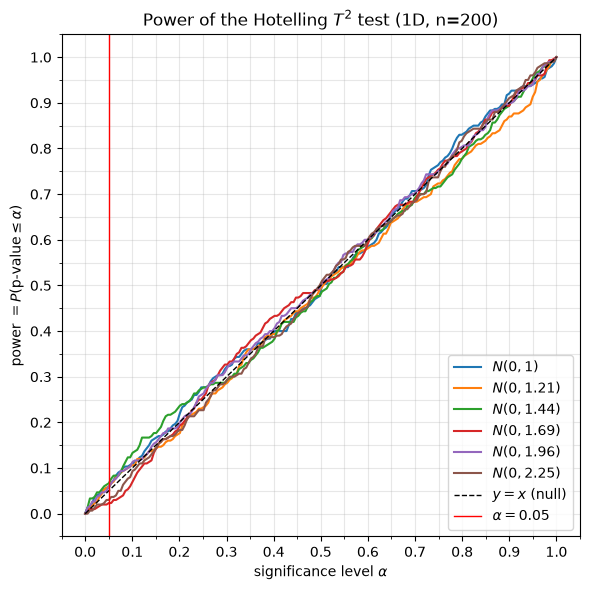

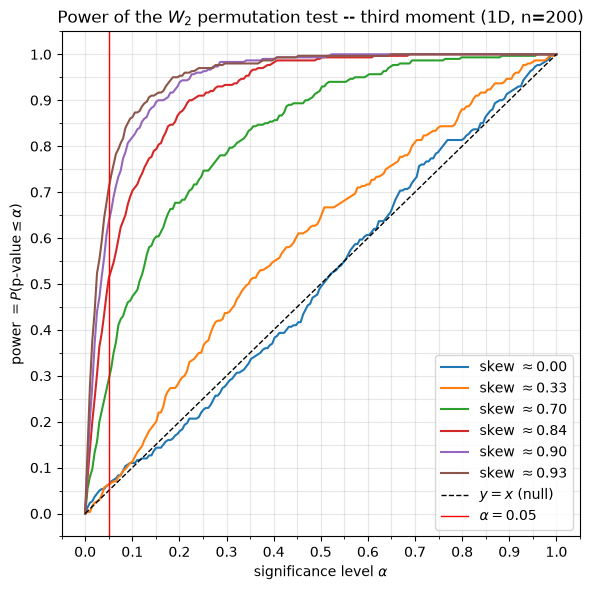

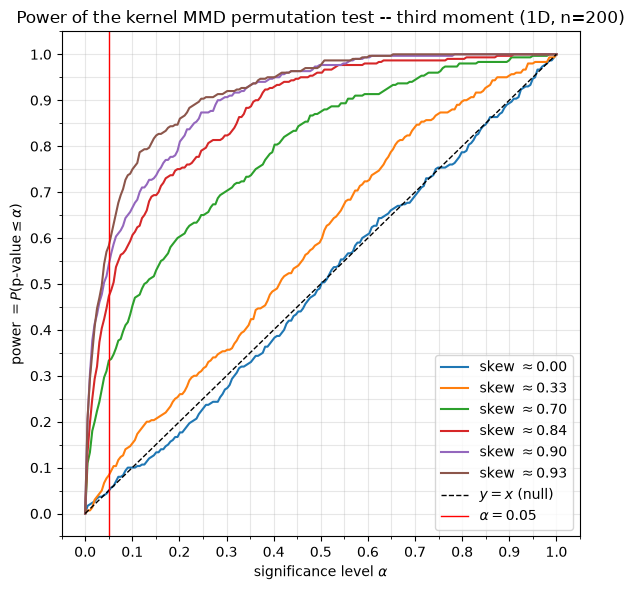

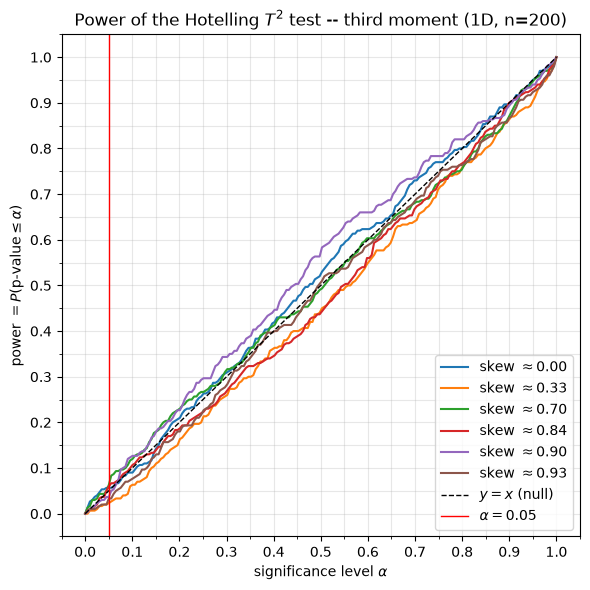

In [12]:
n_val = 200
shift_label = lambda d: f"$N({d:g}, 1)$"
scale_label = lambda s: f"$N(0, {s**2:g})$"
skew_label = lambda a: f"skew $\\approx {float(skewnorm.stats(a, moments='s')):.2f}$"

# every scenario uses the same three tests: Wasserstein, kernel MMD, Hotelling T^2

# mean shift: same variance, different mean
_ = power_curve(normal_shift_1d, deltas, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the $W_2$ permutation test (1D, n={n_val})", pvalue_fn=wasserstein_permutation_pvalue,
                 param_label=shift_label)

_ = power_curve(normal_shift_1d, deltas, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the kernel MMD permutation test (1D, n={n_val})", pvalue_fn=mmd_pvalue,
                 param_label=shift_label)

_ = power_curve(normal_shift_1d, deltas, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the Hotelling $T^2$ test (1D, n={n_val})", pvalue_fn=hotelling_pvalue,
                 param_label=shift_label)

# variance shift: same mean, different variance
_ = power_curve(normal_scale_1d, stds, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the $W_2$ permutation test (1D, n={n_val})", pvalue_fn=wasserstein_permutation_pvalue,
                 param_label=scale_label)

_ = power_curve(normal_scale_1d, stds, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the kernel MMD permutation test (1D, n={n_val})", pvalue_fn=mmd_pvalue,
                 param_label=scale_label)

_ = power_curve(normal_scale_1d, stds, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the Hotelling $T^2$ test (1D, n={n_val})", pvalue_fn=hotelling_pvalue,
                 param_label=scale_label)

# third moment (skewness): same mean AND variance, only skewness differs
_ = power_curve(skew_shift_1d, skews, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the $W_2$ permutation test -- third moment (1D, n={n_val})", pvalue_fn=wasserstein_permutation_pvalue,
                 param_label=skew_label)

_ = power_curve(skew_shift_1d, skews, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the kernel MMD permutation test -- third moment (1D, n={n_val})", pvalue_fn=mmd_pvalue,
                 param_label=skew_label)

_ = power_curve(skew_shift_1d, skews, n_val=n_val, n_reps=300, n_perm=200,
                 title=f"Power of the Hotelling $T^2$ test -- third moment (1D, n={n_val})", pvalue_fn=hotelling_pvalue,
                 param_label=skew_label)

# Two Dimensions

In [13]:
n = 10  # nb samples

mu_s = np.array([0, 0])
cov_s = np.array([[1, 0], [0, 1]])

mu_t = np.array([4, 4])
cov_t = np.array([[1, 0], [0, 1]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n-1, mu_t, cov_t)

xt = np.vstack([xt, [10, 10]])

# loss matrix
M = ot.dist(xs, xt)

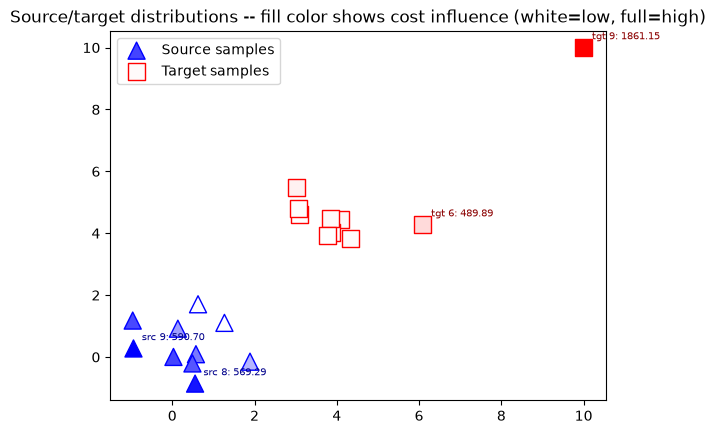

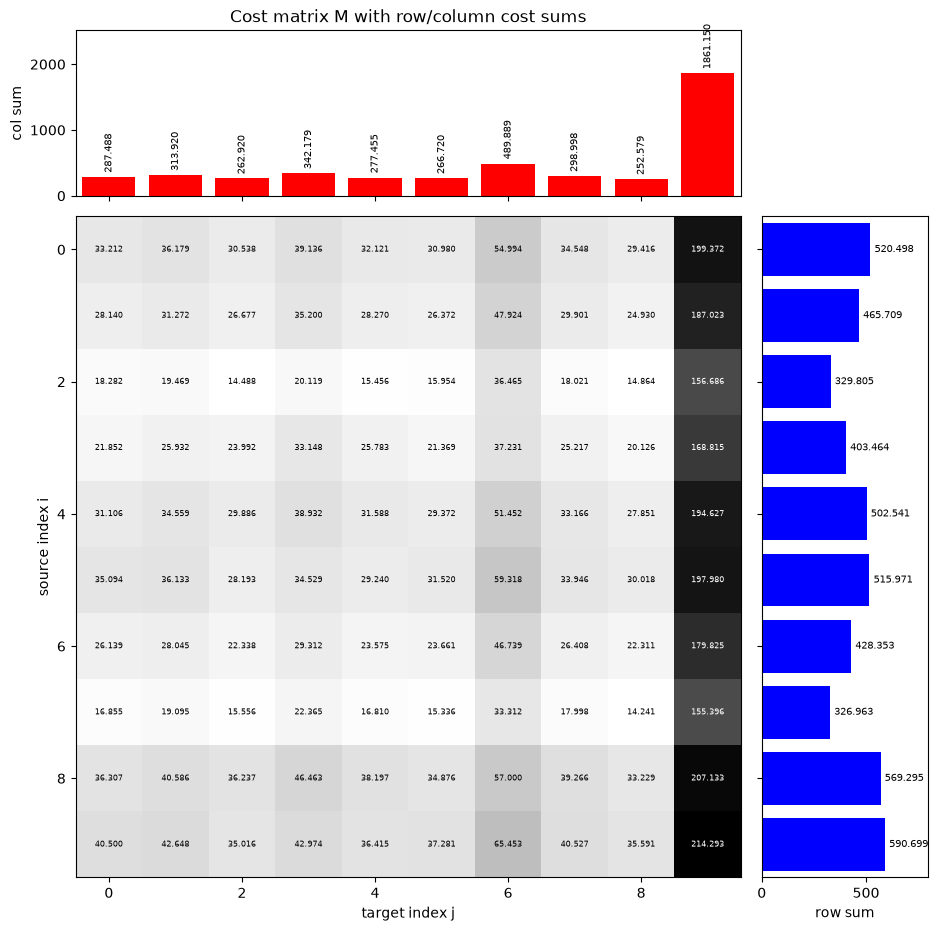

Text(0.5, 1.0, 'OT matrix with samples')

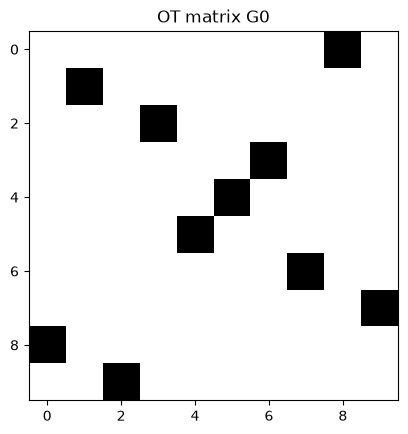

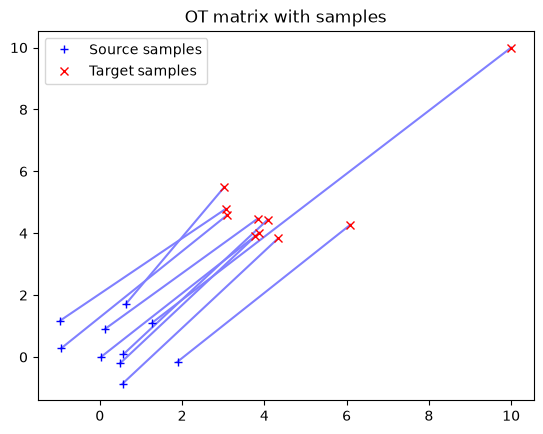

In [14]:
row_sums = M.sum(axis=1)
col_sums = M.sum(axis=0)
# 2D has no natural ordering to sort by (unlike 1D), so instead of index position
# on an axis, label the actual most-costly points directly on the scatter plot
top_src = np.argsort(row_sums)[::-1][:2]  # source points with the highest total cost
top_tgt = np.argsort(col_sums)[::-1][:2]  # target points with the highest total cost

# uniform marker size; influence shown via fill color instead -- white (least
# influential) fading to full blue/red (most influential), same shapes as before
blue_cmap = LinearSegmentedColormap.from_list("white_blue", ["white", "blue"])
red_cmap = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

pl.figure(1)
pl.scatter(xs[:, 0], xs[:, 1], s=150, marker="^", c=row_sums, cmap=blue_cmap,
           edgecolors="blue", linewidths=1, label="Source samples", zorder=2)
pl.scatter(xt[:, 0], xt[:, 1], s=150, marker="s", c=col_sums, cmap=red_cmap,
           edgecolors="red", linewidths=1, label="Target samples", zorder=2)
for i in top_src:
    pl.annotate(f"src {i}: {row_sums[i]:.2f}", (xs[i, 0], xs[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkblue")
for j in top_tgt:
    pl.annotate(f"tgt {j}: {col_sums[j]:.2f}", (xt[j, 0], xt[j, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkred")
pl.legend(loc=0)
pl.title("Source/target distributions -- fill color shows cost influence (white=low, full=high)")

# Cost matrix M -- same annotated treatment as the 1D case: full heatmap with
# individual cost values per cell, plus row/column cost sums as marginal bar
# charts, showing which points are most "influential" (costly on average)
fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j")
ax_main.set_ylabel("source index i")

vmid = (M.max() + M.min()) / 2
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        color = "white" if M[i, j] > vmid else "black"
        ax_main.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums)), col_sums, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M with row/column cost sums")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums)), row_sums, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

G0 = ot.solve(M).plan
#print(ot.solve(M).value)
#print(ot.emd2(a=[],b=[], M=M))

pl.figure(3)
pl.imshow(G0, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix G0")

pl.figure(4)
ot.plot.plot2D_samples_mat(xs, xt, G0, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target samples")
pl.legend(loc=0)
pl.title("OT matrix with samples")

In [15]:
n = 10  # nb samples

mu_s = np.array([0, 0])
cov_s = np.array([[20, 0], [0, 1]])

mu_t = np.array([0, 0])
cov_t = np.array([[1, 0], [0, 1]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

# loss matrix
M = ot.dist(xs, xt)

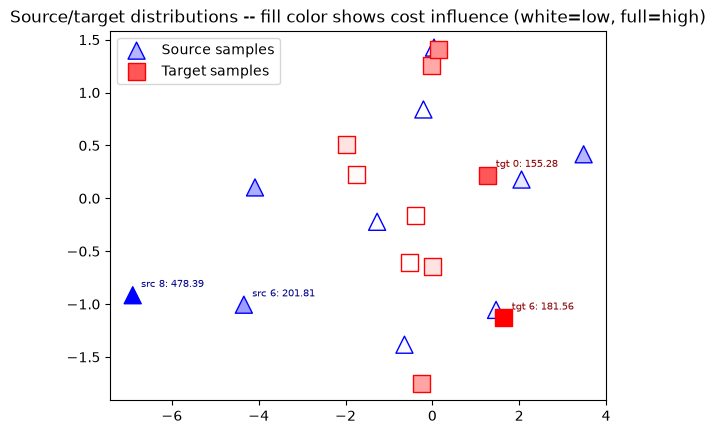

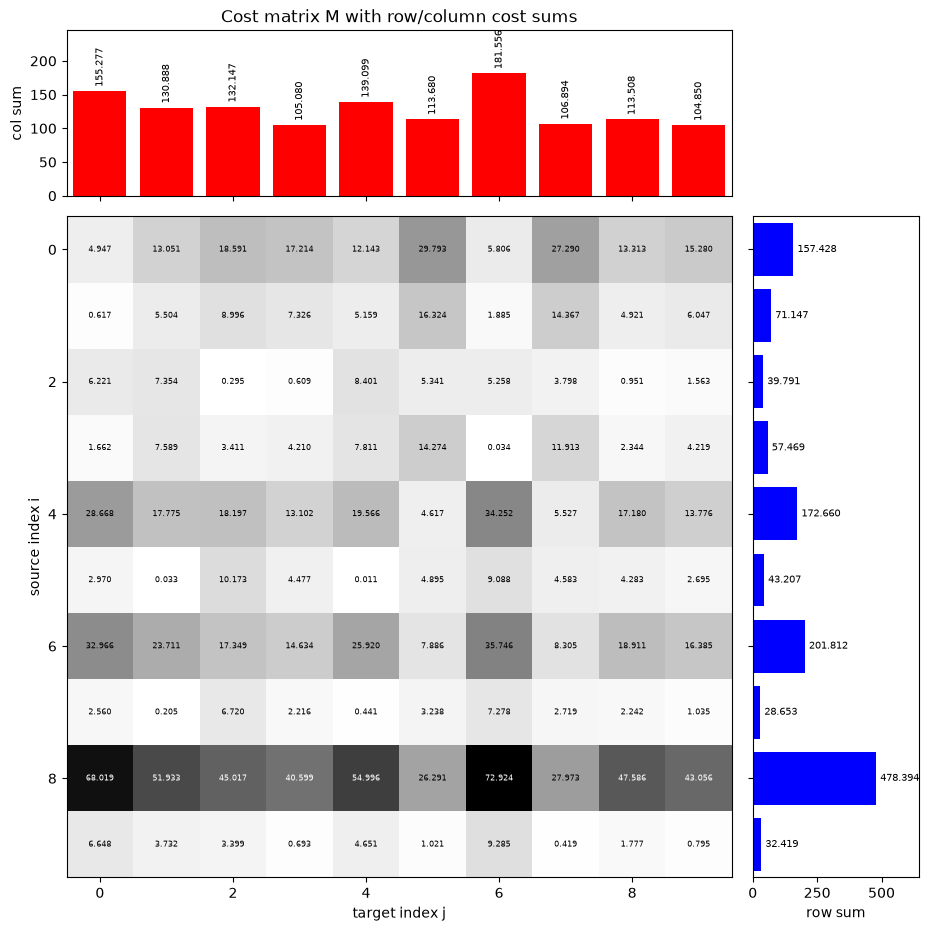

Text(0.5, 1.0, 'OT matrix with samples')

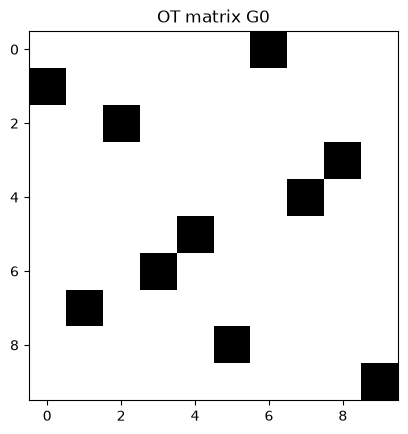

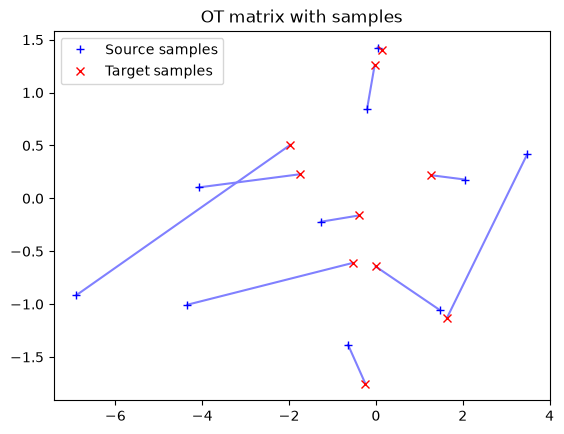

In [16]:
row_sums = M.sum(axis=1)
col_sums = M.sum(axis=0)
# 2D has no natural ordering to sort by (unlike 1D), so instead of index position
# on an axis, label the actual most-costly points directly on the scatter plot
top_src = np.argsort(row_sums)[::-1][:2]  # source points with the highest total cost
top_tgt = np.argsort(col_sums)[::-1][:2]  # target points with the highest total cost

# uniform marker size; influence shown via fill color instead -- white (least
# influential) fading to full blue/red (most influential), same shapes as before
blue_cmap = LinearSegmentedColormap.from_list("white_blue", ["white", "blue"])
red_cmap = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

pl.figure(1)
pl.scatter(xs[:, 0], xs[:, 1], s=150, marker="^", c=row_sums, cmap=blue_cmap,
           edgecolors="blue", linewidths=1, label="Source samples", zorder=2)
pl.scatter(xt[:, 0], xt[:, 1], s=150, marker="s", c=col_sums, cmap=red_cmap,
           edgecolors="red", linewidths=1, label="Target samples", zorder=2)
for i in top_src:
    pl.annotate(f"src {i}: {row_sums[i]:.2f}", (xs[i, 0], xs[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkblue")
for j in top_tgt:
    pl.annotate(f"tgt {j}: {col_sums[j]:.2f}", (xt[j, 0], xt[j, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkred")
pl.legend(loc=0)
pl.title("Source/target distributions -- fill color shows cost influence (white=low, full=high)")

# Cost matrix M -- same annotated treatment as the 1D case: full heatmap with
# individual cost values per cell, plus row/column cost sums as marginal bar
# charts, showing which points are most "influential" (costly on average)
fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j")
ax_main.set_ylabel("source index i")

vmid = (M.max() + M.min()) / 2
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        color = "white" if M[i, j] > vmid else "black"
        ax_main.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums)), col_sums, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M with row/column cost sums")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums)), row_sums, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

G0 = ot.solve(M).plan
#print(ot.solve(M).value)
#print(ot.emd2(a=[],b=[], M=M))

pl.figure(3)
pl.imshow(G0, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix G0")

pl.figure(4)
ot.plot.plot2D_samples_mat(xs, xt, G0, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target samples")
pl.legend(loc=0)
pl.title("OT matrix with samples")

In [17]:
n = 10  # nb samples

mu_s = np.array([5, 5])
cov_s = np.array([[100, 0], [0,1]])

mu_t = np.array([5, 5])
cov_t = np.array([[1, 0], [0, 100]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

# loss matrix
M = ot.dist(xs, xt)

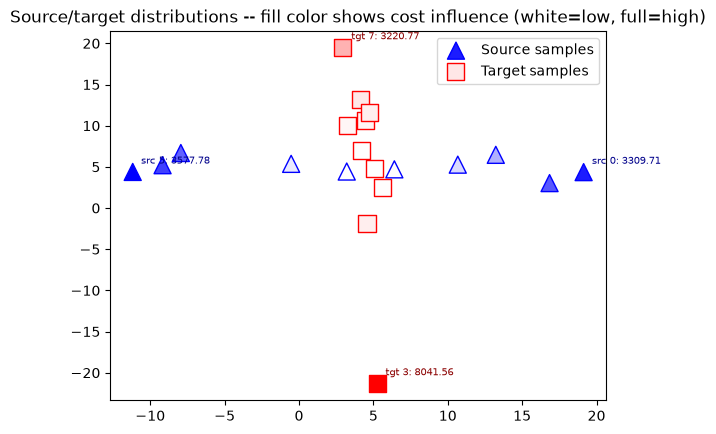

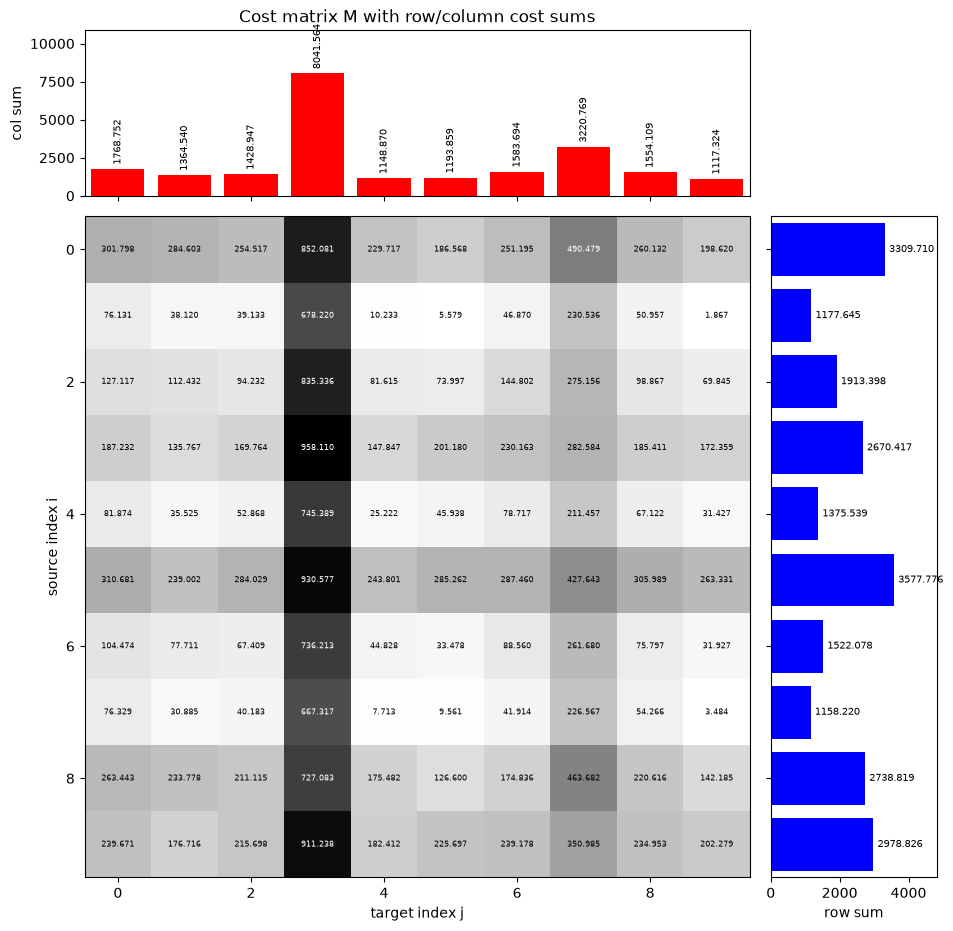

Text(0.5, 1.0, 'OT matrix with samples')

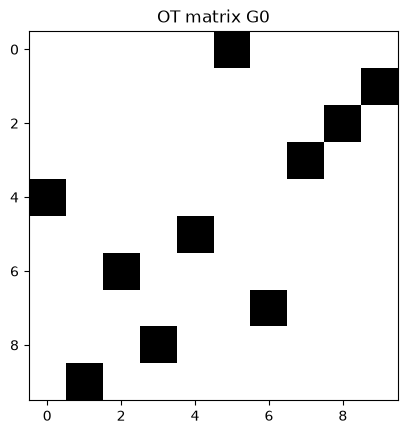

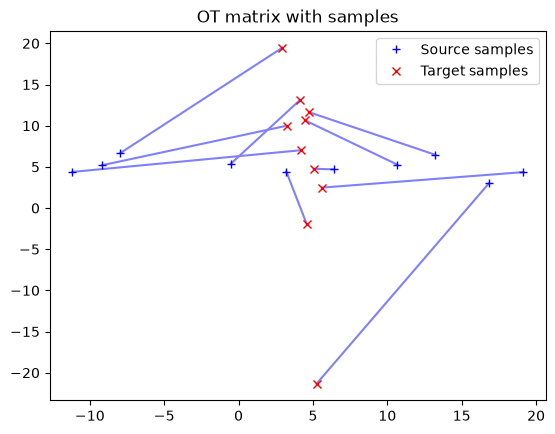

In [ ]:
row_sums = M.sum(axis=1)
col_sums = M.sum(axis=0)
# 2D has no natural ordering to sort by (unlike 1D), so instead of index position
# on an axis, label the actual most-costly points directly on the scatter plot
top_src = np.argsort(row_sums)[::-1][:2]  # source points with the highest total cost
top_tgt = np.argsort(col_sums)[::-1][:2]  # target points with the highest total cost

# uniform marker size; influence shown via fill color instead -- white (least
# influential) fading to full blue/red (most influential), same shapes as before
blue_cmap = LinearSegmentedColormap.from_list("white_blue", ["white", "blue"])
red_cmap = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

pl.figure(1)
pl.scatter(xs[:, 0], xs[:, 1], s=150, marker="^", c=row_sums, cmap=blue_cmap,
           edgecolors="blue", linewidths=1, label="Source samples", zorder=2)
pl.scatter(xt[:, 0], xt[:, 1], s=150, marker="s", c=col_sums, cmap=red_cmap,
           edgecolors="red", linewidths=1, label="Target samples", zorder=2)
for i in top_src:
    pl.annotate(f"src {i}: {row_sums[i]:.2f}", (xs[i, 0], xs[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkblue")
for j in top_tgt:
    pl.annotate(f"tgt {j}: {col_sums[j]:.2f}", (xt[j, 0], xt[j, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkred")
pl.legend(loc=0)
pl.title("Source/target distributions -- fill color shows cost influence (white=low, full=high)")


fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j")
ax_main.set_ylabel("source index i")

vmid = (M.max() + M.min()) / 2
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        color = "white" if M[i, j] > vmid else "black"
        ax_main.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums)), col_sums, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M with row/column cost sums")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums)), row_sums, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

G0 = ot.solve(M).plan
#print(ot.solve(M).value)
#print(ot.emd2(a=[],b=[], M=M))

pl.figure(3)
pl.imshow(G0, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix G0")

pl.figure(4)
ot.plot.plot2D_samples_mat(xs, xt, G0, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target samples")
pl.legend(loc=0)
pl.title("OT matrix with samples")

In [ ]:
n = 10  # nb samples


xs = rng.normal(0.0, 1.0, (n, 2))
xt = np.column_stack([standardized_skewnorm(8.0, n, rng) for _ in range(2)])

# loss matrix
M = ot.dist(xs, xt)

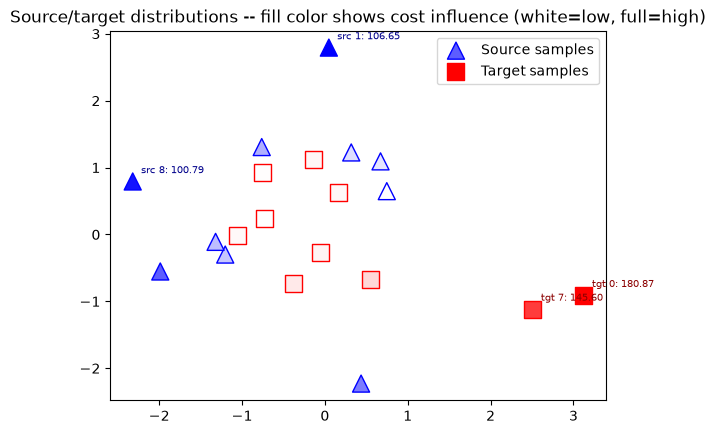

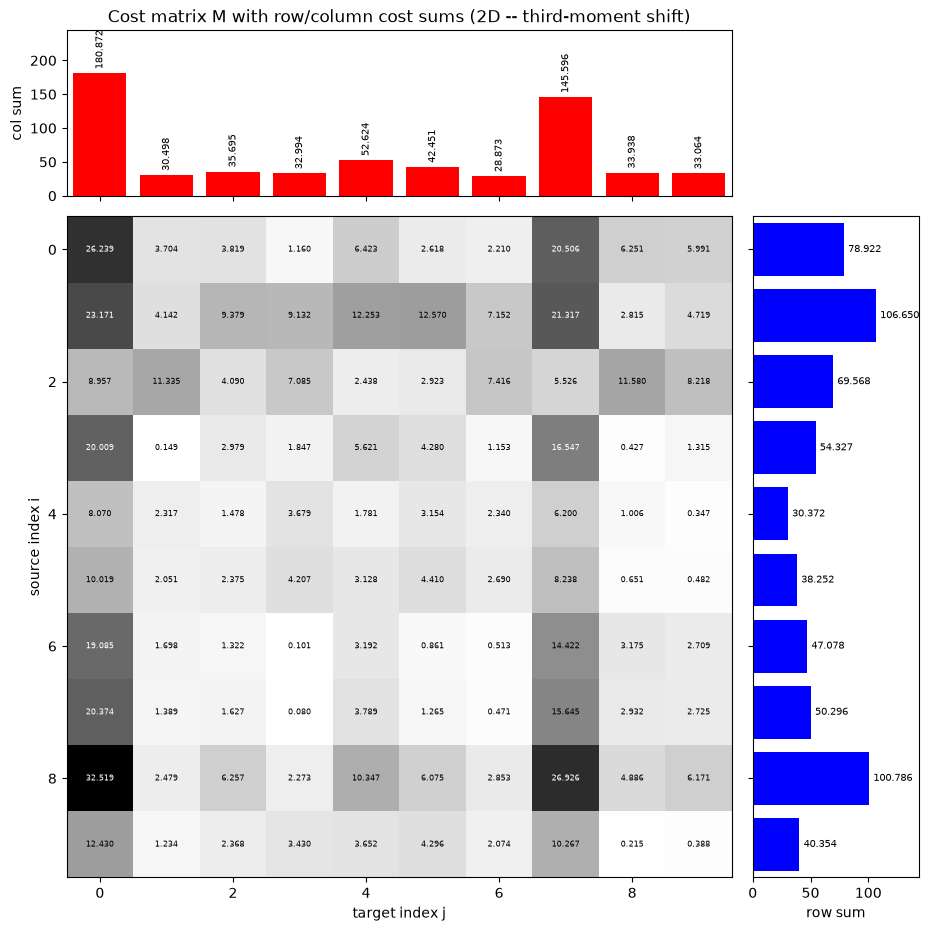

Text(0.5, 1.0, 'OT matrix with samples (2D -- third-moment shift)')

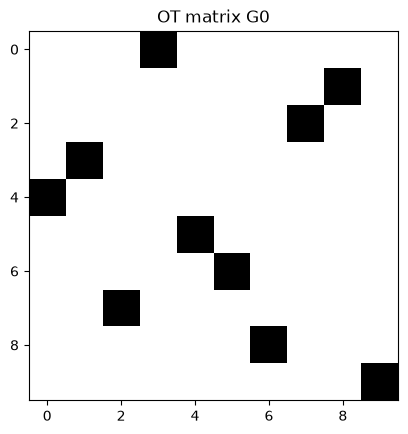

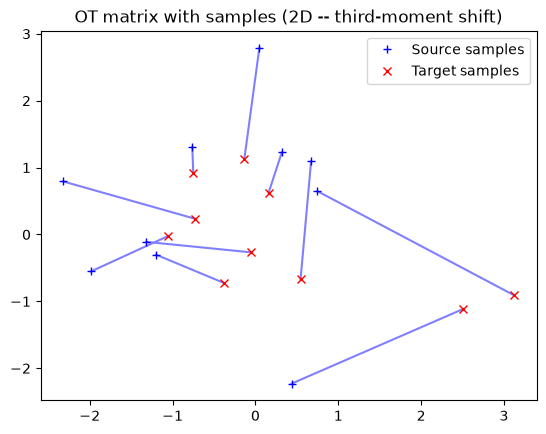

In [ ]:
row_sums = M.sum(axis=1)
col_sums = M.sum(axis=0)
# 2D has no natural ordering to sort by (unlike 1D), so instead of index position
# on an axis, label the actual most-costly points directly on the scatter plot
top_src = np.argsort(row_sums)[::-1][:2]  # source points with the highest total cost
top_tgt = np.argsort(col_sums)[::-1][:2]  # target points with the highest total cost

# uniform marker size; influence shown via fill color instead -- white (least
# influential) fading to full blue/red (most influential), same shapes as before
blue_cmap = LinearSegmentedColormap.from_list("white_blue", ["white", "blue"])
red_cmap = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

pl.figure(1)
pl.scatter(xs[:, 0], xs[:, 1], s=150, marker="^", c=row_sums, cmap=blue_cmap,
           edgecolors="blue", linewidths=1, label="Source samples", zorder=2)
pl.scatter(xt[:, 0], xt[:, 1], s=150, marker="s", c=col_sums, cmap=red_cmap,
           edgecolors="red", linewidths=1, label="Target samples", zorder=2)
for i in top_src:
    pl.annotate(f"src {i}: {row_sums[i]:.2f}", (xs[i, 0], xs[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkblue")
for j in top_tgt:
    pl.annotate(f"tgt {j}: {col_sums[j]:.2f}", (xt[j, 0], xt[j, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=7, color="darkred")
pl.legend(loc=0)
pl.title("Source/target distributions -- fill color shows cost influence (white=low, full=high)")


fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j")
ax_main.set_ylabel("source index i")

vmid = (M.max() + M.min()) / 2
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        color = "white" if M[i, j] > vmid else "black"
        ax_main.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums)), col_sums, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M with row/column cost sums (2D -- third-moment shift)")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums)), row_sums, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

G0 = ot.solve(M).plan

pl.figure(3)
pl.imshow(G0, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix G0")

pl.figure(4)
ot.plot.plot2D_samples_mat(xs, xt, G0, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target samples")
pl.legend(loc=0)
pl.title("OT matrix with samples (2D -- third-moment shift)")

In [21]:
n = 10  # nb samples

mu_s = np.array([0, 0])
cov_s = np.array([[1, 0], [0, 1]])

mu_t = np.array([4, 4])
cov_t = np.array([[1, 0], [0, 1]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n-1, mu_t, cov_t)

xt = np.vstack([xt, [10, 10]])

# loss matrix
M = ot.dist(xs, xt)

In [22]:
n = 10  # nb samples

mu_s = np.array([0, 0])
cov_s = np.array([[20, 0], [0, 1]])

mu_t = np.array([0, 0])
cov_t = np.array([[1, 0], [0, 1]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

# loss matrix
M = ot.dist(xs, xt)

In [23]:
n = 10  # nb samples

mu_s = np.array([5, 5])
cov_s = np.array([[100, 0], [0,1]])

mu_t = np.array([5, 5])
cov_t = np.array([[1, 0], [0, 100]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

# loss matrix
M = ot.dist(xs, xt)

In [ ]:
n_val = 200


def normal_shift_2d(delta, n_val, rng):
    """Same variance (I), different mean (delta, delta). X and Y from
    independent rng substreams."""
    rx, ry = rng.spawn(2)
    X = rx.normal([0.0, 0.0], 1.0, (n_val, 2))
    Y = ry.normal([delta, delta], 1.0, (n_val, 2))
    return X, Y


def normal_scale_2d(var, n_val, rng):
    """Same mean (0,0), isotropic covariance var*I vs I -- the 2D analogue of
    normal_scale_1d. X and Y from independent rng substreams."""
    rx, ry = rng.spawn(2)
    X = rx.multivariate_normal([0.0, 0.0], [[1, 0], [0, 1]], n_val)
    Y = ry.multivariate_normal([0.0, 0.0], [[var, 0], [0, var]], n_val)
    return X, Y


def skew_shift_2d(alpha, n_val, rng):
    rx, ry = rng.spawn(2)
    X = rx.normal(0.0, 1.0, (n_val, 2))
    Y = np.column_stack([standardized_skewnorm(alpha, n_val, ry) for _ in range(2)])
    return X, Y


variances_2d = np.linspace(1, 1.5, 6)

shift_label_2d = lambda d: f"$N(({d:g},{d:g}),\\,I)$"
scale_label_2d = lambda v: f"$N(0,\\,{v**2:g}I)$"
skew_label_2d = lambda a: f"per-coord skew $\\approx {float(skewnorm.stats(a, moments='s')):.2f}$"


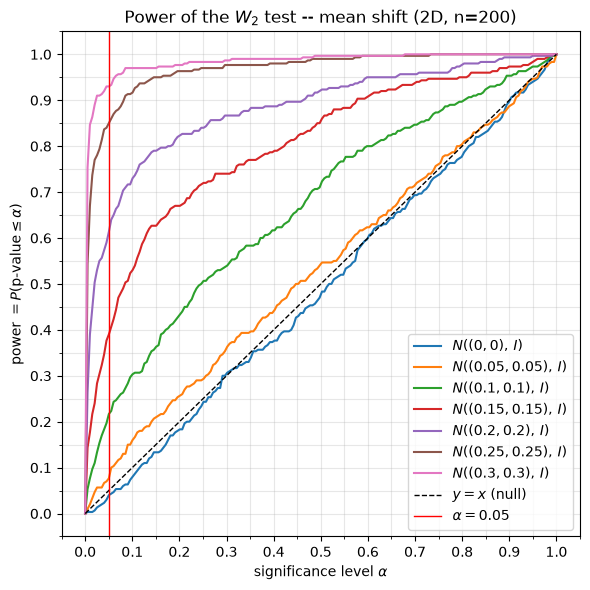

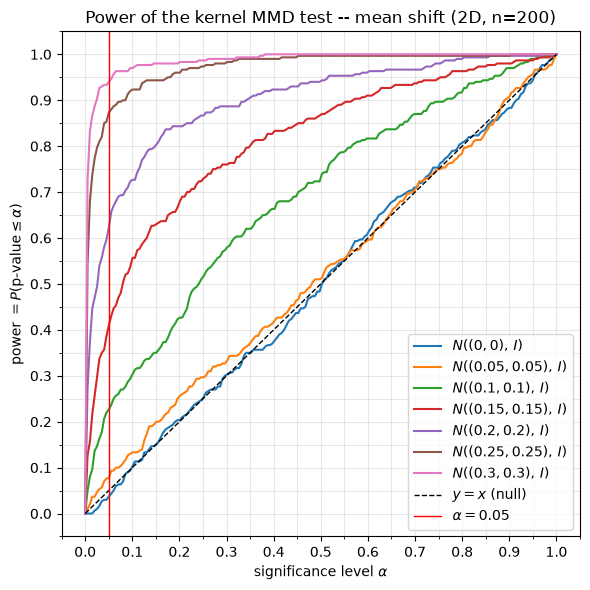

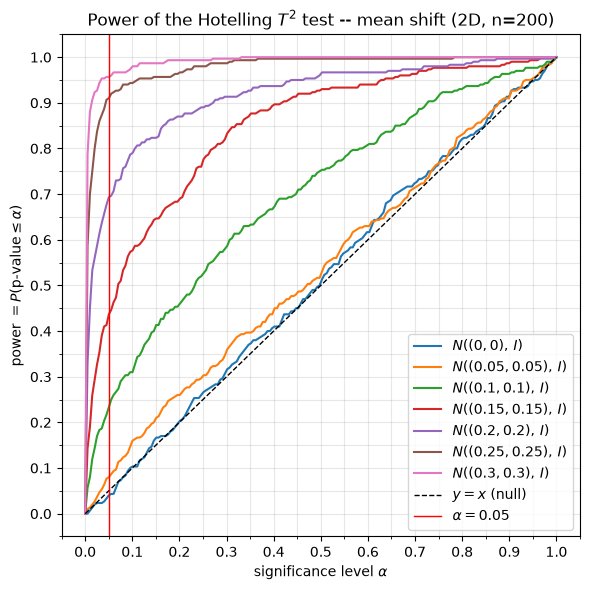

In [ ]:
mean_tests = [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")]
var_tests = [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")]
skew_tests = [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")]

# 1) mean shift: same variance (I), different mean (delta, delta)
for pvalue_fn, name in mean_tests:
    _ = power_curve(normal_shift_2d, deltas, n_val=n_val, n_reps=300, n_perm=200,
                     title=f"Power of the {name} test -- mean shift (2D, n={n_val})",
                     pvalue_fn=pvalue_fn, param_label=shift_label_2d)


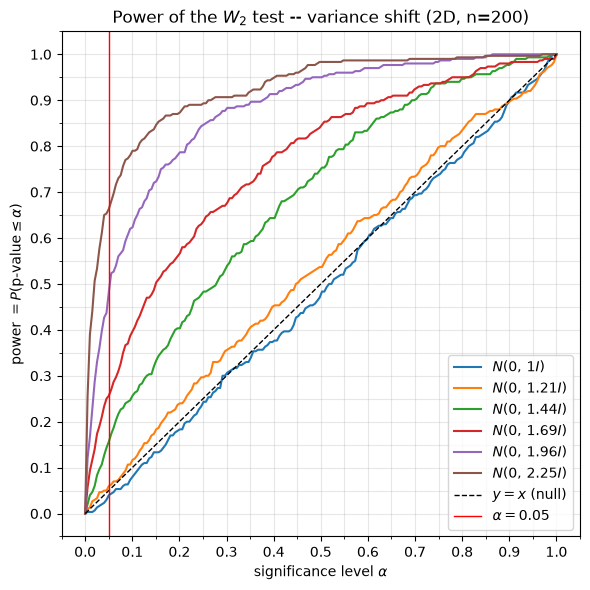

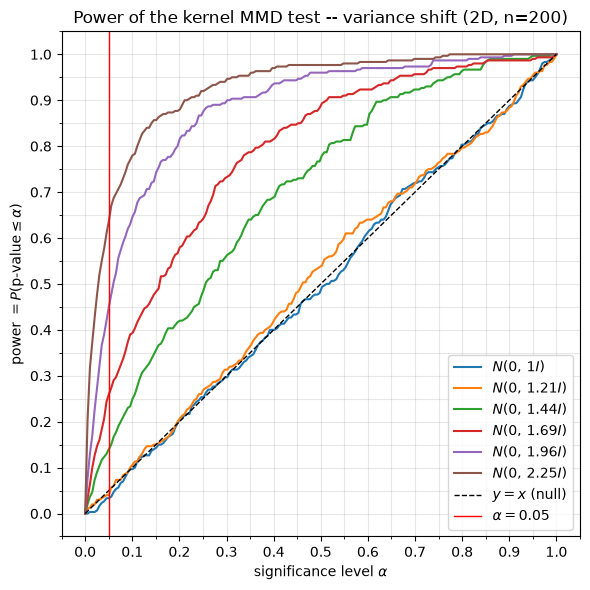

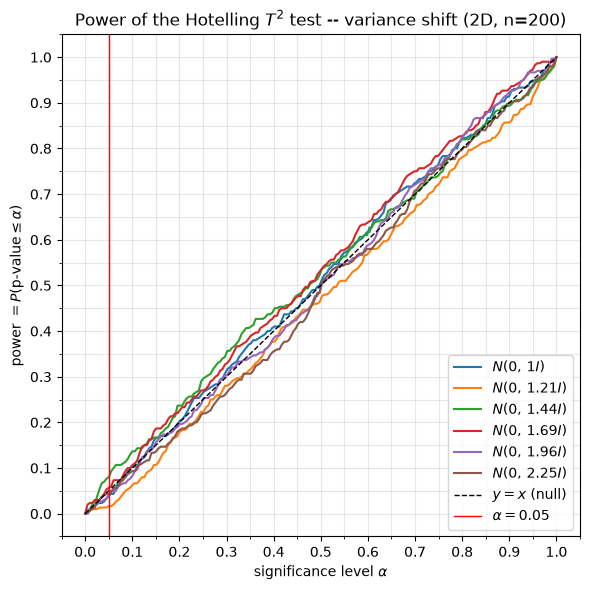

In [26]:

# 2) variance shift: same mean (0,0), isotropic variance var*I vs I
for pvalue_fn, name in var_tests:
    _ = power_curve(normal_scale_2d, variances_2d, n_val=n_val, n_reps=300, n_perm=200,
                     title=f"Power of the {name} test -- variance shift (2D, n={n_val})",
                     pvalue_fn=pvalue_fn, param_label=scale_label_2d)


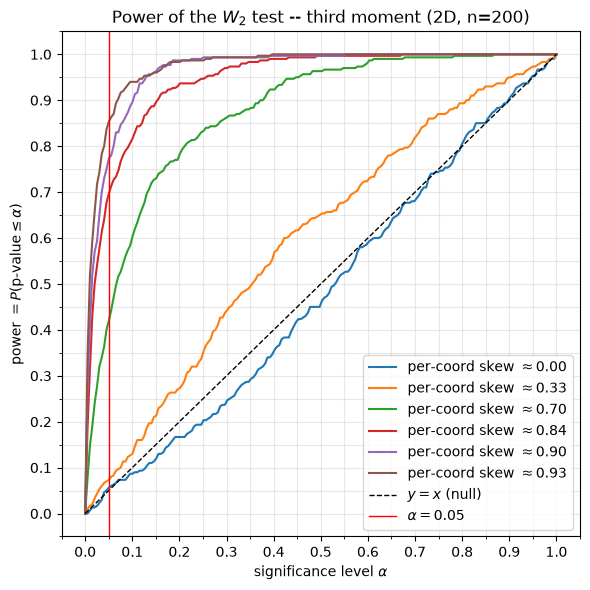

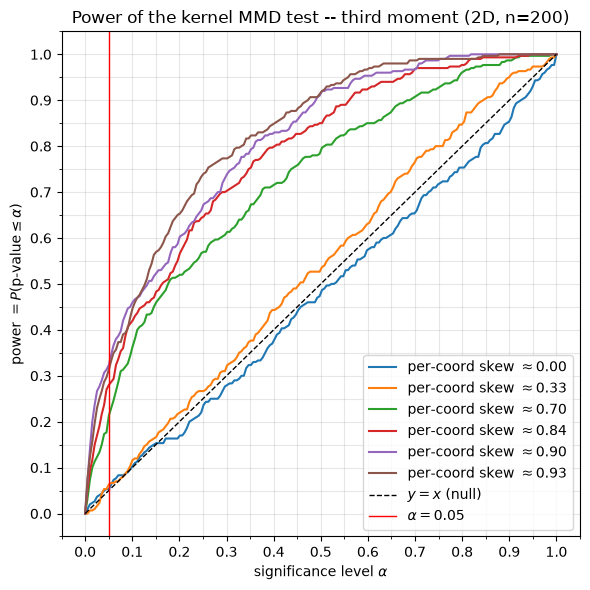

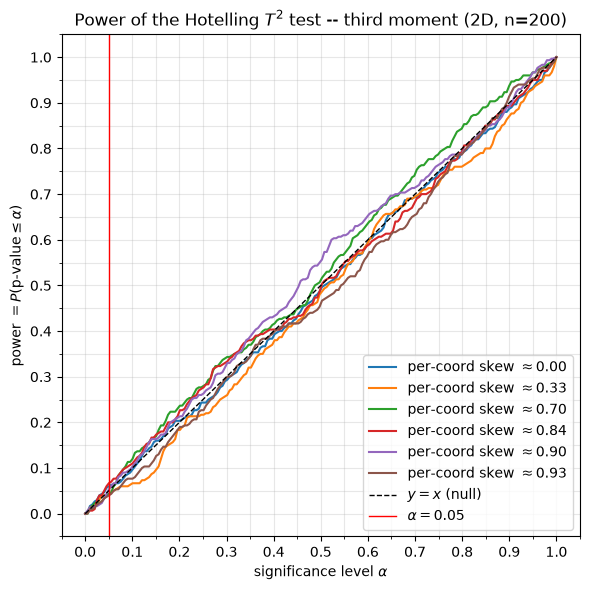

In [27]:

# 3) skewness: same mean AND variance, only the (per-coordinate) third moment differs
for pvalue_fn, name in skew_tests:
    _ = power_curve(skew_shift_2d, skews, n_val=n_val, n_reps=300, n_perm=200,
                     title=f"Power of the {name} test -- third moment (2D, n={n_val})",
                     pvalue_fn=pvalue_fn, param_label=skew_label_2d)

# 20 dimensions

In [ ]:
d = 20
n_val = 200


def normal_shift_20d(delta, n_val, rng):
    rx, ry = rng.spawn(2)
    X = rx.multivariate_normal(np.zeros(d), np.eye(d), n_val)
    Y = ry.multivariate_normal(np.full(d, delta), np.eye(d), n_val)
    return X, Y


def normal_scale_20d(var, n_val, rng):
    rx, ry = rng.spawn(2)
    X = rx.multivariate_normal(np.zeros(d), np.eye(d), n_val)
    Y = ry.multivariate_normal(np.zeros(d), var * np.eye(d), n_val)
    return X, Y


def skew_shift_20d(alpha, n_val, rng):
    """Same mean (zeros(20)) and identity covariance, but each of the 20
    coordinates of Y is an independent standardized skew-normal with shape
    `alpha` -- only the per-coordinate third moment differs. X and Y from
    independent substreams."""
    rx, ry = rng.spawn(2)
    X = rx.normal(0.0, 1.0, (n_val, d))
    Y = np.column_stack([standardized_skewnorm(alpha, n_val, ry) for _ in range(d)])
    return X, Y


shift_label_20d = lambda delta: f"mean shift {delta:g} (all 20 dims)"
scale_label_20d = lambda v: f"variance {v**2:g} (isotropic, all 20 dims)"
skew_label_20d = lambda a: f"per-coord skew $\\approx {float(skewnorm.stats(a, moments='s')):.2f}$ (all 20 dims)"

mean_tests = [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")]
var_tests = [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")]
skew_tests = [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")]


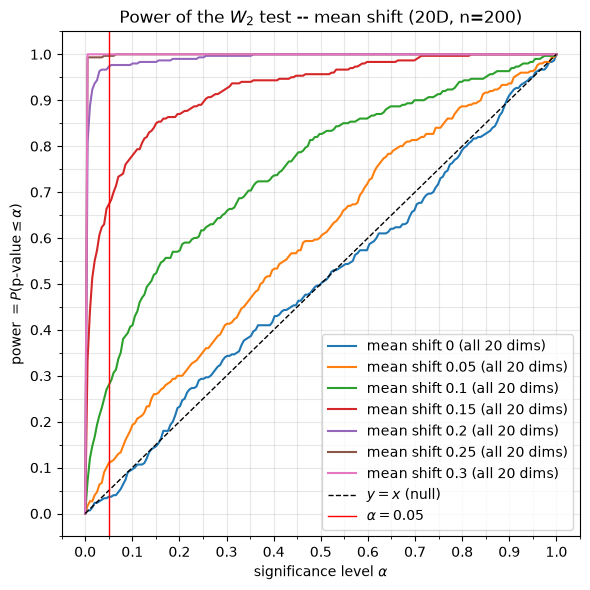

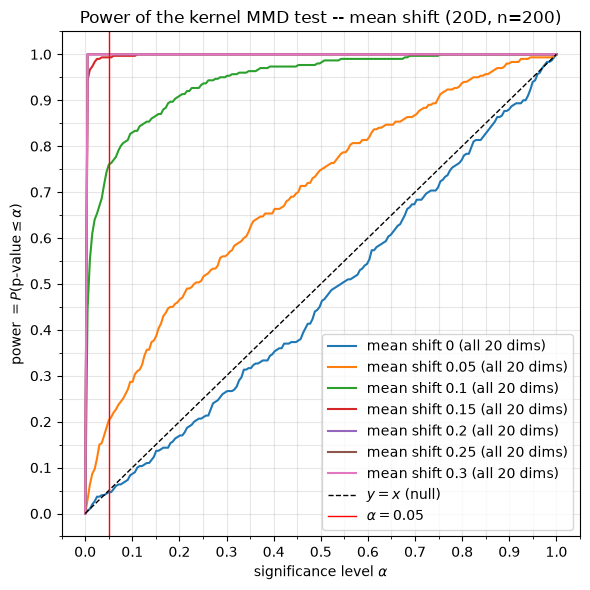

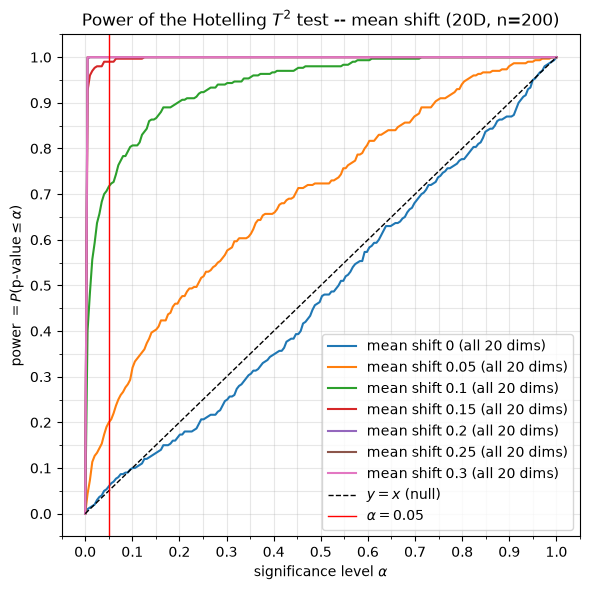

In [29]:

# 1) mean shift, same variance
for pvalue_fn, name in mean_tests:
    _ = power_curve(normal_shift_20d, deltas, n_val=n_val, n_reps=300, n_perm=200,
                     title=f"Power of the {name} test -- mean shift (20D, n={n_val})",
                     pvalue_fn=pvalue_fn, param_label=shift_label_20d)


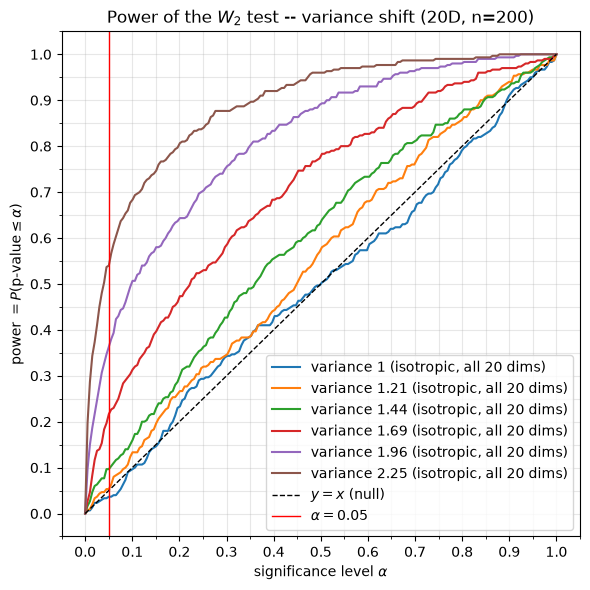

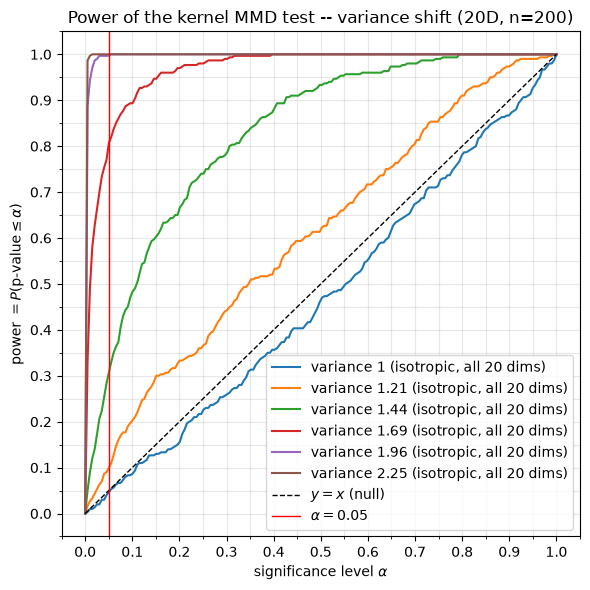

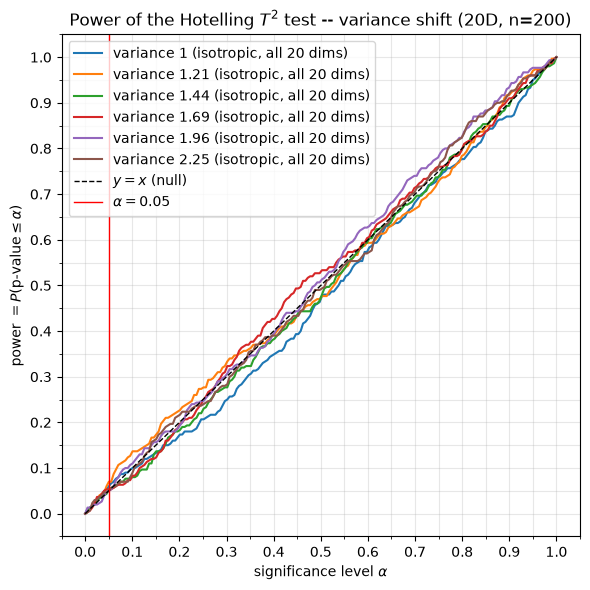

In [30]:

# 2) variance shift, same mean
for pvalue_fn, name in var_tests:
    _ = power_curve(normal_scale_20d, variances_2d, n_val=n_val, n_reps=300, n_perm=200,
                     title=f"Power of the {name} test -- variance shift (20D, n={n_val})",
                     pvalue_fn=pvalue_fn, param_label=scale_label_20d)


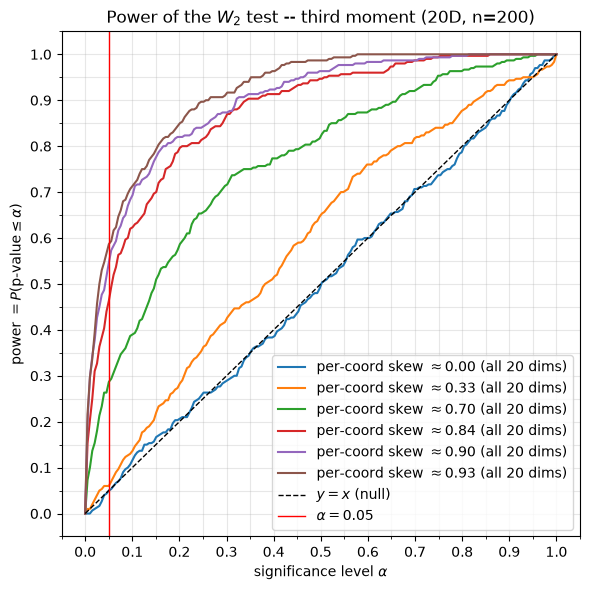

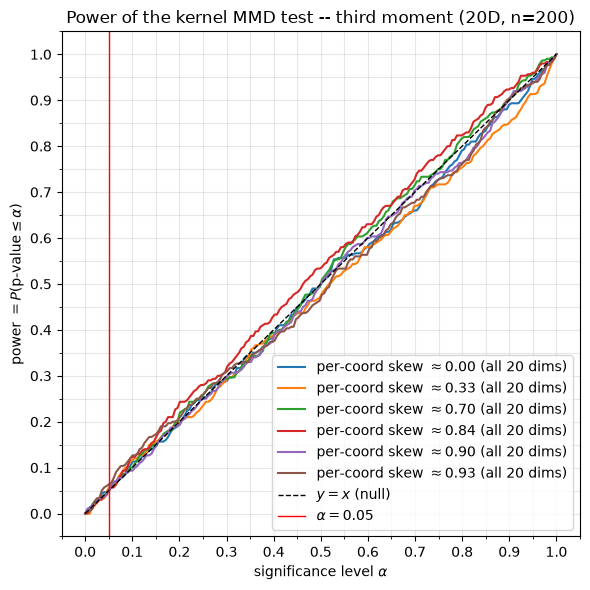

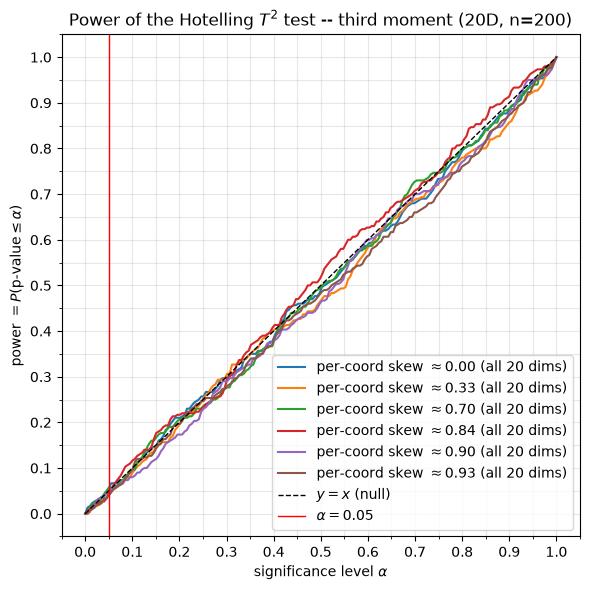

In [31]:

# 3) skewness, same mean AND variance
for pvalue_fn, name in skew_tests:
    _ = power_curve(skew_shift_20d, skews, n_val=n_val, n_reps=300, n_perm=200,
                     title=f"Power of the {name} test -- third moment (20D, n={n_val})",
                     pvalue_fn=pvalue_fn, param_label=skew_label_20d)

# Power at $\alpha=0.05$ vs effect size



In [ ]:
from joblib import Parallel, delayed


def power_vs_param_at_alpha(sample_fn, params, n_val, pvalue_tests, alpha=0.05,
                            n_reps=300, n_perm=200, seed=0, n_jobs=6):
    """Power at a FIXED level `alpha` as a function of the effect-size parameter.
    For each param, all tests see the SAME simulated datasets (shared child
    seeds -- same scheme as the main power_curve cells). Each test contributes
    power = mean(pvalue <= alpha). Returns {test_name: [power at each param]}."""
    results = {name: [] for _, name in pvalue_tests}
    param_seeds = np.random.SeedSequence(seed).spawn(len(params))
    for param, ps in zip(params, param_seeds):
        child_seeds = ps.spawn(n_reps)
        for fn, name in pvalue_tests:
            def _one(cs, f=fn, pm=param):
                warnings.filterwarnings("ignore", message="The number of replications is low")
                r = np.random.default_rng(cs)
                Xi, Yi = sample_fn(pm, n_val, r)
                return f(Xi, Yi, n_perm=n_perm, rng=r)
            pv = np.array(Parallel(n_jobs=n_jobs)(delayed(_one)(cs) for cs in child_seeds))
            results[name].append(float(np.mean(pv <= alpha)))
    return results


def plot_power_vs_param(results, params, xlabel, title, alpha=0.05):
    """Overlay each test's power-at-alpha as a function of the effect-size param."""
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for name, powers in results.items():
        ax.plot(list(params), powers, marker="o", label=name)
    ax.axhline(alpha, color="red", lw=1, ls="--", label=rf"nominal level $\alpha={alpha:g}$")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(rf"power at $\alpha={alpha:g}$")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.legend()
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

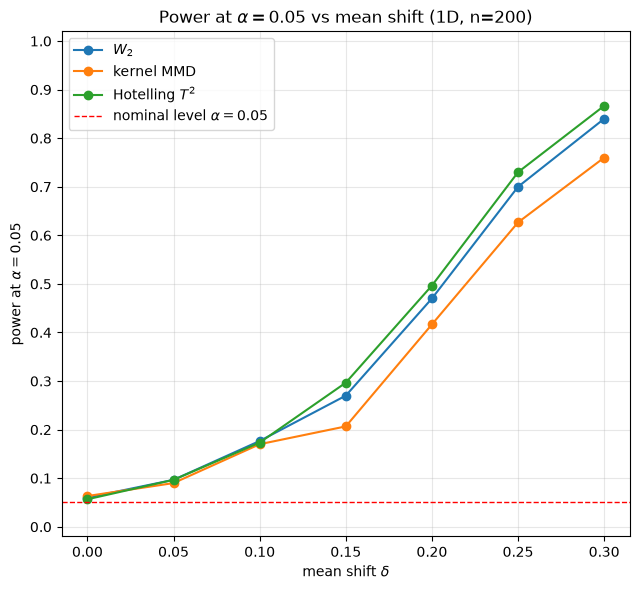

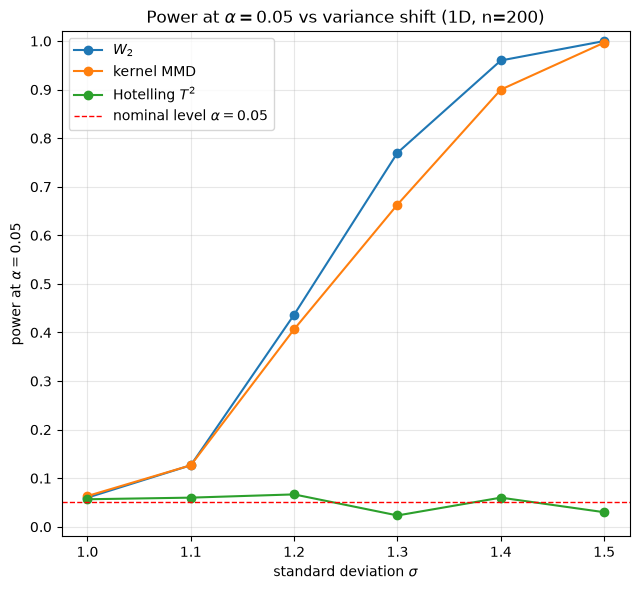

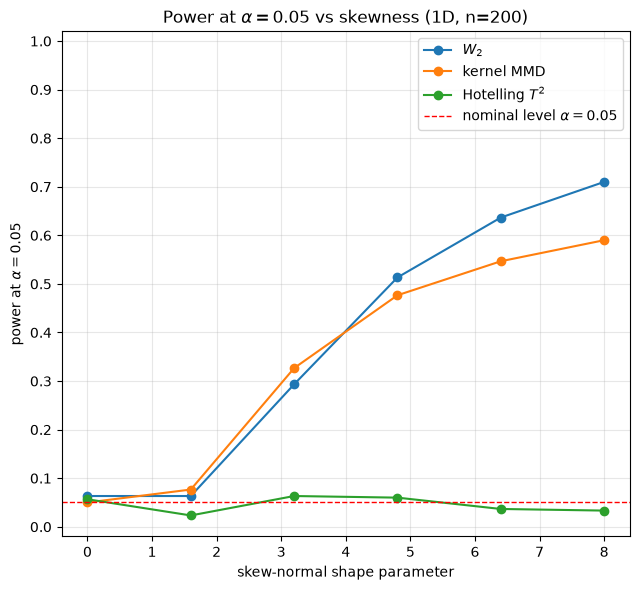

In [33]:
# 1D: power at alpha=0.05 vs effect size
res = power_vs_param_at_alpha(normal_shift_1d, list(deltas), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, deltas, r"mean shift $\delta$", r"Power at $\alpha=0.05$ vs mean shift (1D, n=200)")

res = power_vs_param_at_alpha(normal_scale_1d, list(stds), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, stds, r"standard deviation $\sigma$", r"Power at $\alpha=0.05$ vs variance shift (1D, n=200)")

res = power_vs_param_at_alpha(skew_shift_1d, list(skews), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, skews, "skew-normal shape parameter", r"Power at $\alpha=0.05$ vs skewness (1D, n=200)")

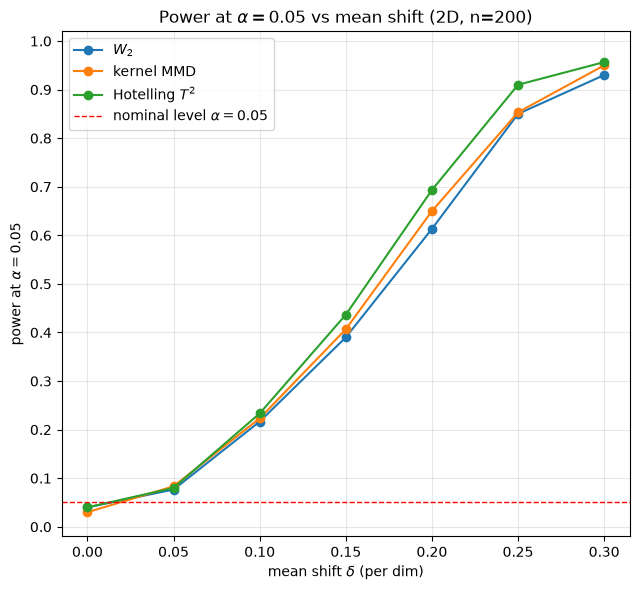

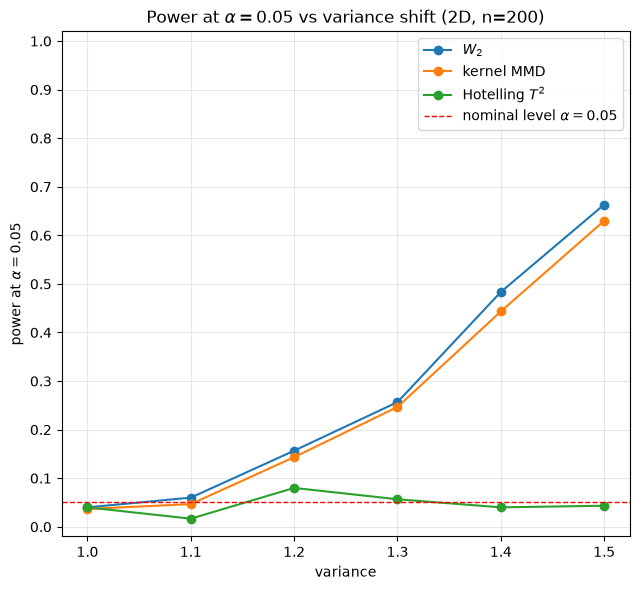

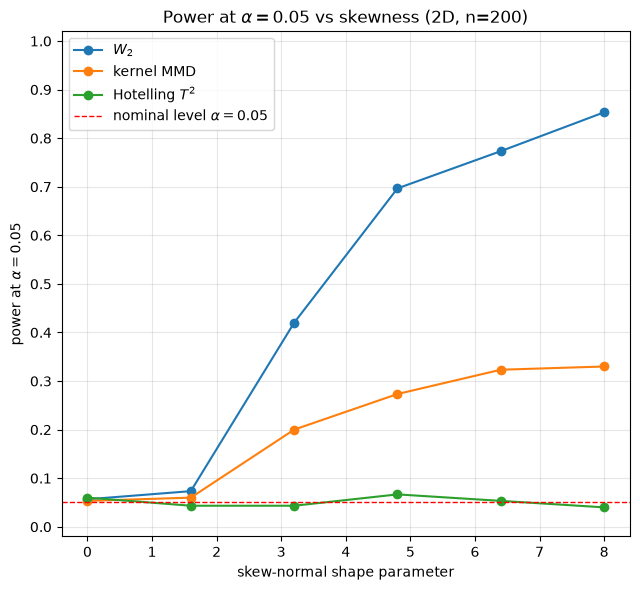

In [34]:
# 2D: power at alpha=0.05 vs effect size
res = power_vs_param_at_alpha(normal_shift_2d, list(deltas), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, deltas, r"mean shift $\delta$ (per dim)", r"Power at $\alpha=0.05$ vs mean shift (2D, n=200)")

res = power_vs_param_at_alpha(normal_scale_2d, list(variances_2d), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, variances_2d, "variance", r"Power at $\alpha=0.05$ vs variance shift (2D, n=200)")

res = power_vs_param_at_alpha(skew_shift_2d, list(skews), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, skews, "skew-normal shape parameter", r"Power at $\alpha=0.05$ vs skewness (2D, n=200)")

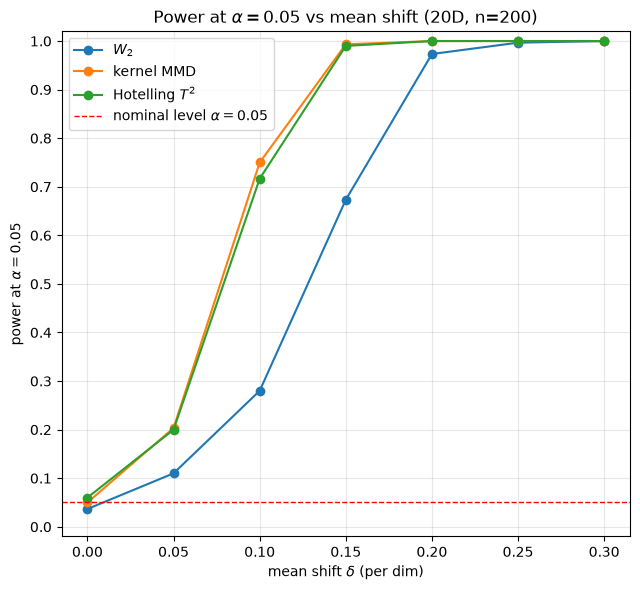

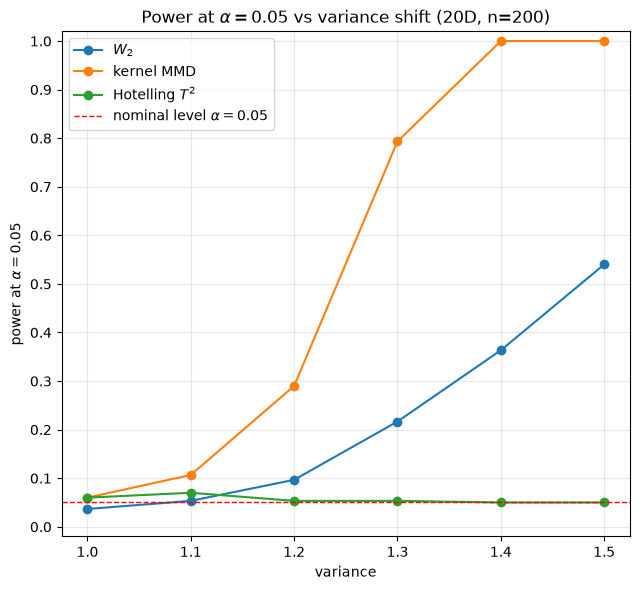

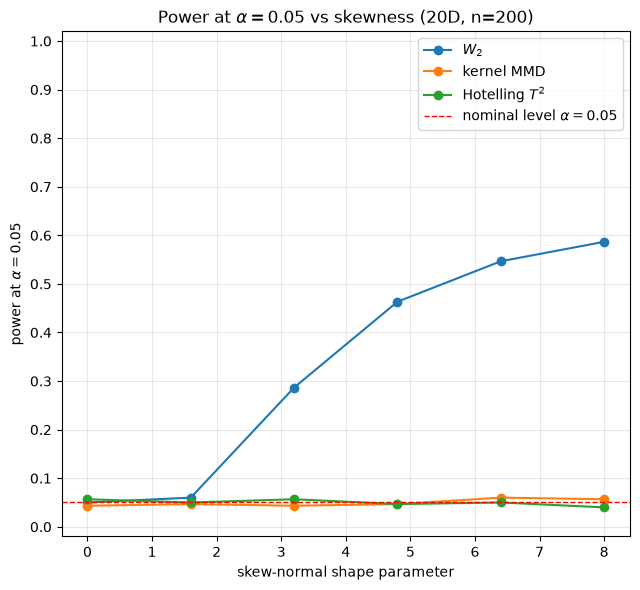

In [35]:
# 20D: power at alpha=0.05 vs effect size
res = power_vs_param_at_alpha(normal_shift_20d, list(deltas), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, deltas, r"mean shift $\delta$ (per dim)", r"Power at $\alpha=0.05$ vs mean shift (20D, n=200)")

res = power_vs_param_at_alpha(normal_scale_20d, list(variances_2d), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, variances_2d, "variance", r"Power at $\alpha=0.05$ vs variance shift (20D, n=200)")

res = power_vs_param_at_alpha(skew_shift_20d, list(skews), 200,
        [(wasserstein_permutation_pvalue, "$W_2$"), (mmd_pvalue, "kernel MMD"), (hotelling_pvalue, "Hotelling $T^2$")])
plot_power_vs_param(res, skews, "skew-normal shape parameter", r"Power at $\alpha=0.05$ vs skewness (20D, n=200)")

# MMD bandwidth-sensitivity check


In [ ]:
from joblib import Parallel, delayed
from hyppo.ksample import MMD
from scipy.spatial.distance import pdist


def mmd_pvalue_gamma(x, y, gamma, n_perm=200, rng=None):
    """hyppo Gaussian MMD permutation p-value at a specific RBF `gamma`
    (gamma = 1 / (2 * bandwidth**2)); the single-bandwidth building block whose
    power we probe as the bandwidth varies."""
    x = np.asarray(x, dtype=float).reshape(len(x), -1)
    y = np.asarray(y, dtype=float).reshape(len(y), -1)
    _, pval = MMD(compute_kernel="gaussian", gamma=gamma).test(x, y, reps=n_perm, workers=1, auto=False, random_state=rng)
    return float(pval)


def bandwidth_power_check(sample_fn, param, n_val, title, exponents=np.arange(-6, 7),
                          n_reps=300, n_perm=200, alpha=0.05, seed=0, n_jobs=6):
    """Power at level `alpha` of the single-bandwidth Gaussian MMD as a function
    of the kernel bandwidth, for a fixed scenario/effect size. For each rep the
    bandwidth grid is the median heuristic (pooled median pairwise distance)
    times 2**(exponents/2) -- Gretton's convention -- so the x-axis is a multiple
    of each dataset's own median heuristic. This shows how much a single
    bandwidth's power swings with the (otherwise arbitrary) choice. Same seeding
    scheme as the main cells."""
    mults = 2.0 ** (exponents / 2)
    child_seeds = np.random.SeedSequence(seed).spawn(n_reps)

    def _one(cs):
        warnings.filterwarnings("ignore", message="The number of replications is low")
        r = np.random.default_rng(cs)
        Xi, Yi = sample_fn(param, n_val, r)
        xi = np.asarray(Xi, dtype=float).reshape(len(Xi), -1)
        yi = np.asarray(Yi, dtype=float).reshape(len(Yi), -1)
        sigma_med = np.median(pdist(np.vstack([xi, yi])))
        gammas = 1.0 / (2.0 * (sigma_med * mults) ** 2)
        return [mmd_pvalue_gamma(xi, yi, float(g), n_perm=n_perm, rng=r) for g in gammas]

    pvals = np.array(Parallel(n_jobs=n_jobs)(delayed(_one)(cs) for cs in child_seeds))  # (n_reps, n_bw)
    power_bw = np.mean(pvals <= alpha, axis=0)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot(mults, power_bw, marker="o", label="single-bandwidth Gaussian MMD")
    ax.axvline(1.0, color="gray", lw=1, ls=":", label="median heuristic (hyppo default)")
    ax.set_xscale("log", base=2)
    ax.set_xlabel(r"bandwidth / median heuristic")
    ax.set_ylabel(rf"power at $\alpha={alpha:g}$")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return mults, power_bw

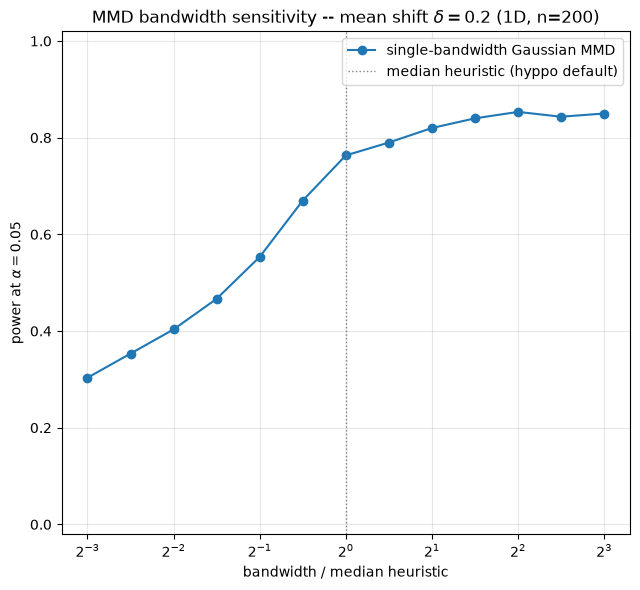

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.30333333, 0.35333333, 0.40333333, 0.46666667, 0.55333333,
        0.67      , 0.76333333, 0.79      , 0.82      , 0.84      ,
        0.85333333, 0.84333333, 0.85      ]))

In [53]:
# 1D bandwidth-sensitivity checks at a representative effect size per family
# (edit the parameter values to taste)
bandwidth_power_check(normal_shift_1d, 0.3, 200, r"MMD bandwidth sensitivity -- mean shift $\delta=0.2$ (1D, n=200)")


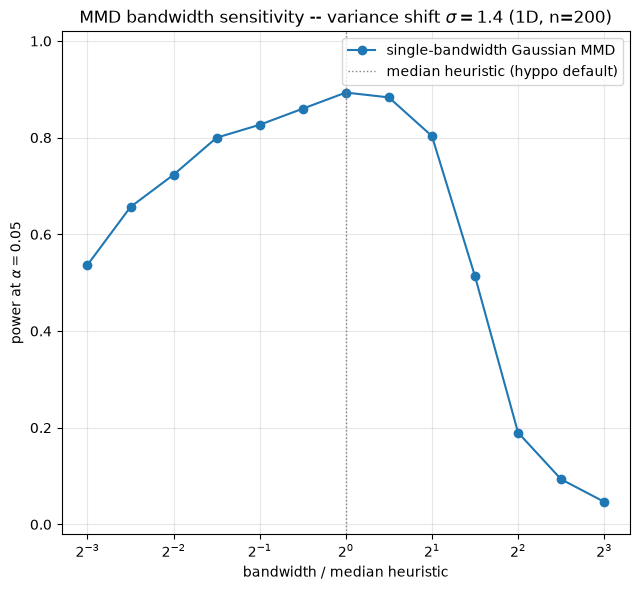

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.53666667, 0.65666667, 0.72333333, 0.8       , 0.82666667,
        0.86      , 0.89333333, 0.88333333, 0.80333333, 0.51333333,
        0.19      , 0.09333333, 0.04666667]))

In [54]:

bandwidth_power_check(normal_scale_1d, 1.4, 200, r"MMD bandwidth sensitivity -- variance shift $\sigma=1.4$ (1D, n=200)")


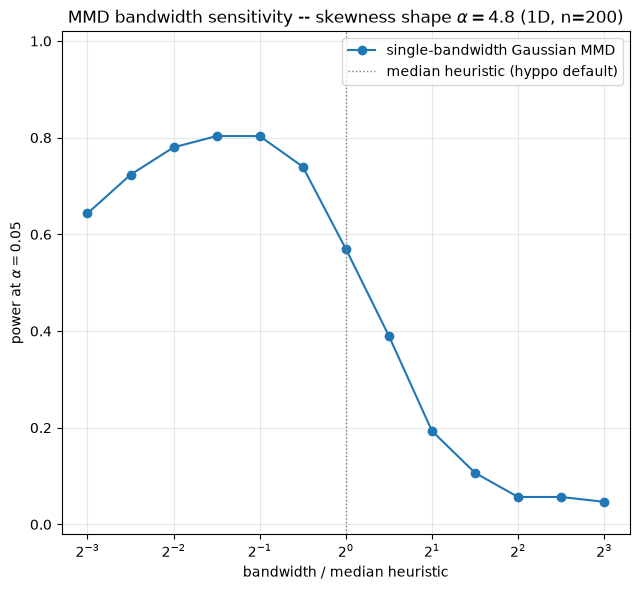

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.64333333, 0.72333333, 0.78      , 0.80333333, 0.80333333,
        0.74      , 0.57      , 0.39      , 0.19333333, 0.10666667,
        0.05666667, 0.05666667, 0.04666667]))

In [55]:

bandwidth_power_check(skew_shift_1d, 8.0, 200, r"MMD bandwidth sensitivity -- skewness shape $\alpha=4.8$ (1D, n=200)")

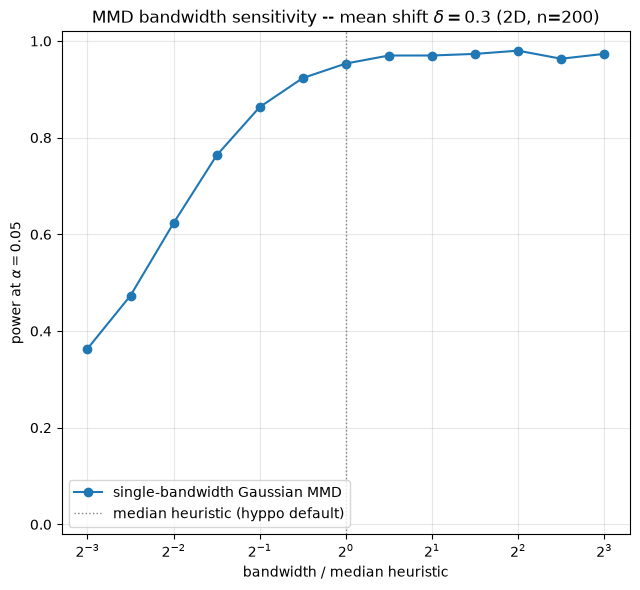

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.36333333, 0.47333333, 0.62333333, 0.76333333, 0.86333333,
        0.92333333, 0.95333333, 0.97      , 0.97      , 0.97333333,
        0.98      , 0.96333333, 0.97333333]))

In [56]:
# 2D bandwidth-sensitivity checks
bandwidth_power_check(normal_shift_2d, 0.3, 200, r"MMD bandwidth sensitivity -- mean shift $\delta=0.3$ (2D, n=200)")


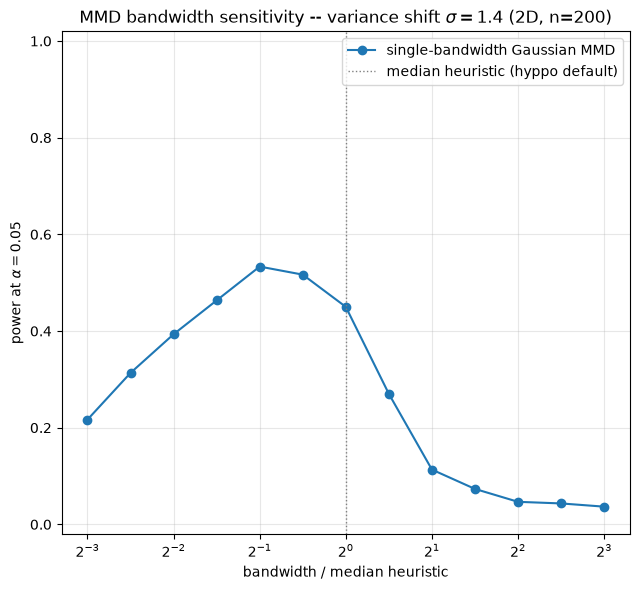

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.21666667, 0.31333333, 0.39333333, 0.46333333, 0.53333333,
        0.51666667, 0.45      , 0.27      , 0.11333333, 0.07333333,
        0.04666667, 0.04333333, 0.03666667]))

In [57]:

bandwidth_power_check(normal_scale_2d, 1.4, 200, r"MMD bandwidth sensitivity -- variance shift $\sigma=1.4$ (2D, n=200)")


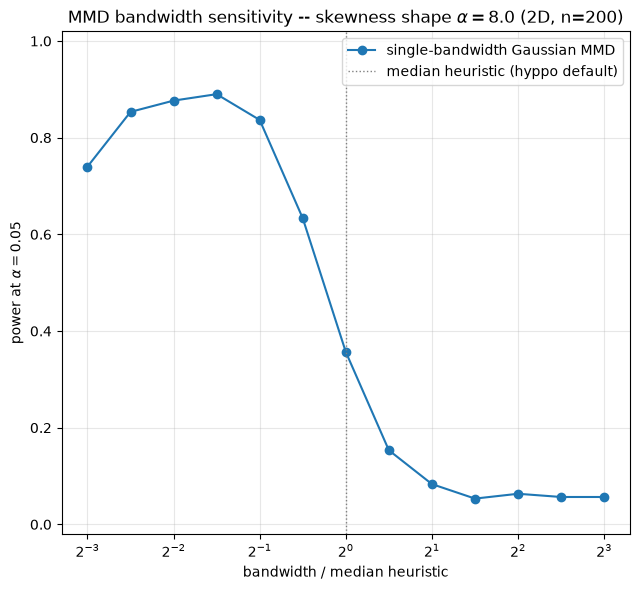

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.74      , 0.85333333, 0.87666667, 0.89      , 0.83666667,
        0.63333333, 0.35666667, 0.15333333, 0.08333333, 0.05333333,
        0.06333333, 0.05666667, 0.05666667]))

In [58]:

bandwidth_power_check(skew_shift_2d, 8.0, 200, r"MMD bandwidth sensitivity -- skewness shape $\alpha=8.0$ (2D, n=200)")

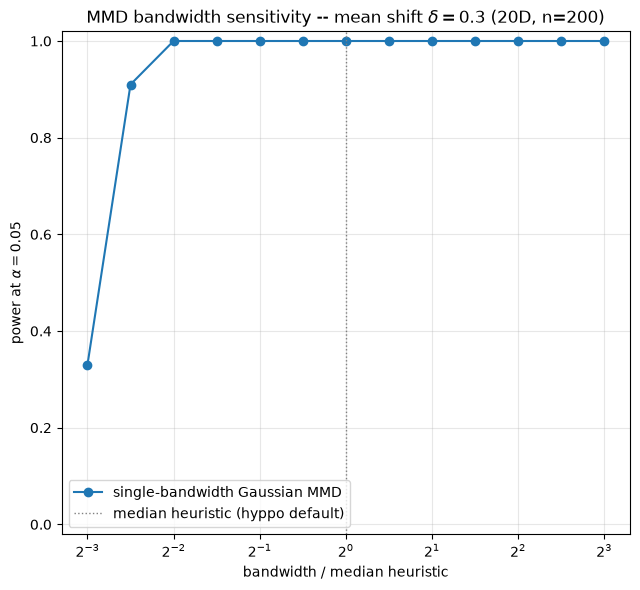

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.33, 0.91, 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  ]))

In [59]:
# 20D bandwidth-sensitivity checks
bandwidth_power_check(normal_shift_20d, 0.3, 200, r"MMD bandwidth sensitivity -- mean shift $\delta=0.3$ (20D, n=200)")


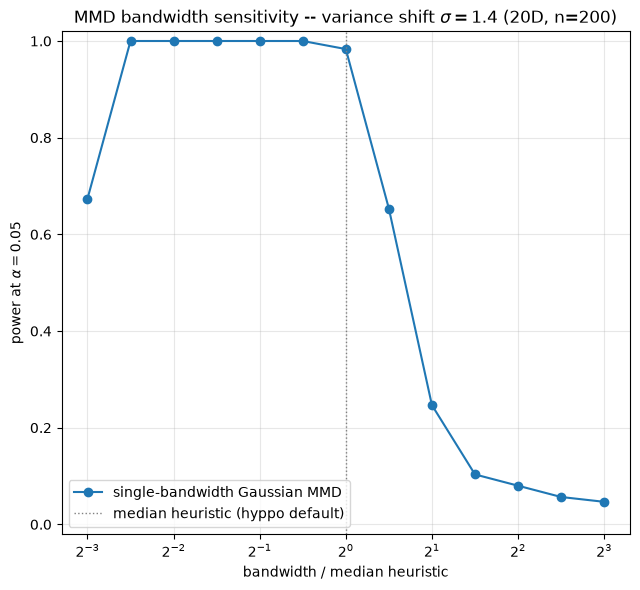

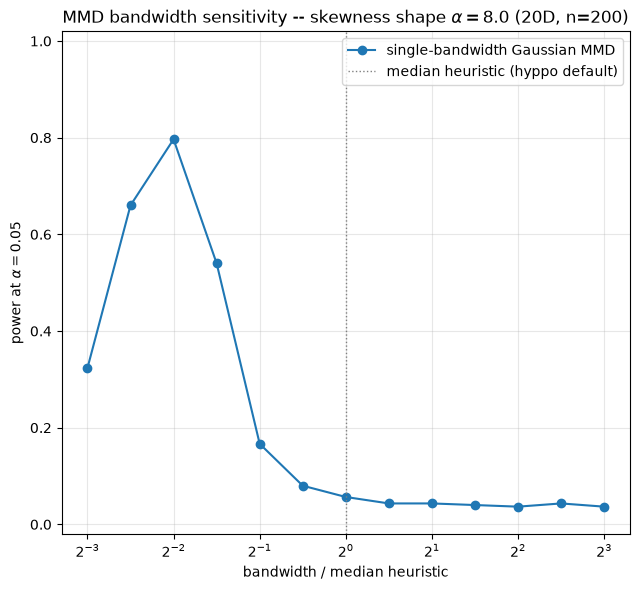

(array([0.125     , 0.1767767 , 0.25      , 0.35355339, 0.5       ,
        0.70710678, 1.        , 1.41421356, 2.        , 2.82842712,
        4.        , 5.65685425, 8.        ]),
 array([0.32333333, 0.66      , 0.79666667, 0.54      , 0.16666667,
        0.08      , 0.05666667, 0.04333333, 0.04333333, 0.04      ,
        0.03666667, 0.04333333, 0.03666667]))

In [60]:

bandwidth_power_check(normal_scale_20d, 1.4, 200, r"MMD bandwidth sensitivity -- variance shift $\sigma=1.4$ (20D, n=200)")
bandwidth_power_check(skew_shift_20d, 8.0, 200, r"MMD bandwidth sensitivity -- skewness shape $\alpha=8.0$ (20D, n=200)")

average cost per matched pair -- optimal (sorted-to-sorted): 12.051
average cost per matched pair -- non-optimal (reverse order): 14.551


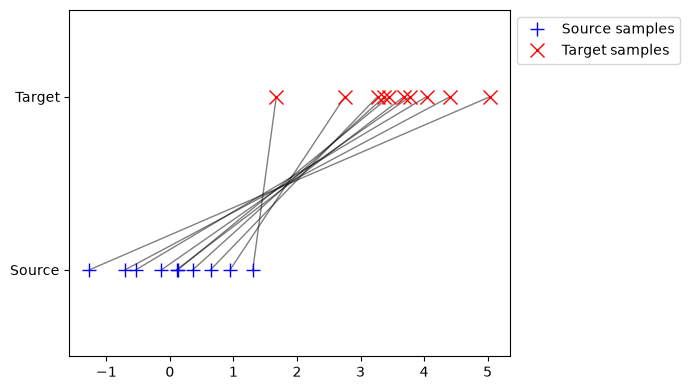

In [ ]:
M_11 = ot.dist(x_1.reshape(-1, 1), y_1.reshape(-1, 1))
perm_bad = np.arange(len(x_1))[::-1]          # reverse order: i -> n-1-i
rows_bad, cols_bad = np.arange(len(x_1)), perm_bad

pl.figure(figsize=(7, 4))
for i, j in zip(rows_bad, cols_bad):
    pl.plot([x_1[i], y_1[j]], [y_source, y_target], "k-", alpha=0.5, lw=1, zorder=1)
pl.plot(x_1, np.full_like(x_1, y_source), "+b", label="Source samples", markersize=10, zorder=2)
pl.plot(y_1, np.full_like(y_1, y_target), "xr", label="Target samples", markersize=10, zorder=2)
pl.yticks([y_source, y_target], ["Source", "Target"])
pl.ylim(-0.5, 1.5)
pl.legend(loc="upper left", bbox_to_anchor=(1, 1))
pl.tight_layout()

# cost comparison: the non-optimal coupling must cost at least as much as the
# optimal one (that's what "optimal" means) -- confirm it numerically
cost_optimal = M_11[rows, cols].sum() / len(x_1)
cost_bad = M_11[rows_bad, cols_bad].sum() / len(x_1)
print(f"average cost per matched pair -- optimal (sorted-to-sorted): {cost_optimal:.3f}")
print(f"average cost per matched pair -- non-optimal (reverse order): {cost_bad:.3f}")

# Extra 1D examples: identical distributions, and a single outlier



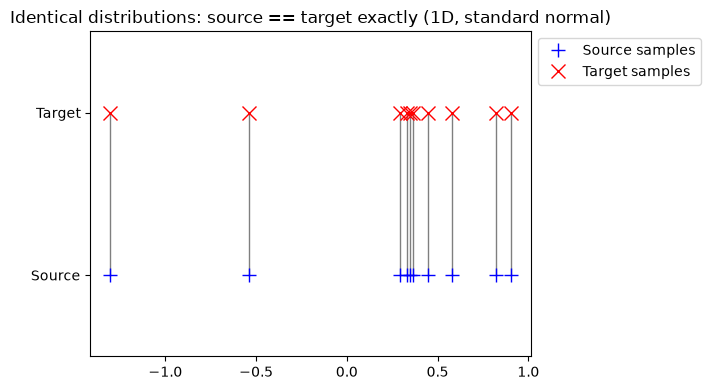

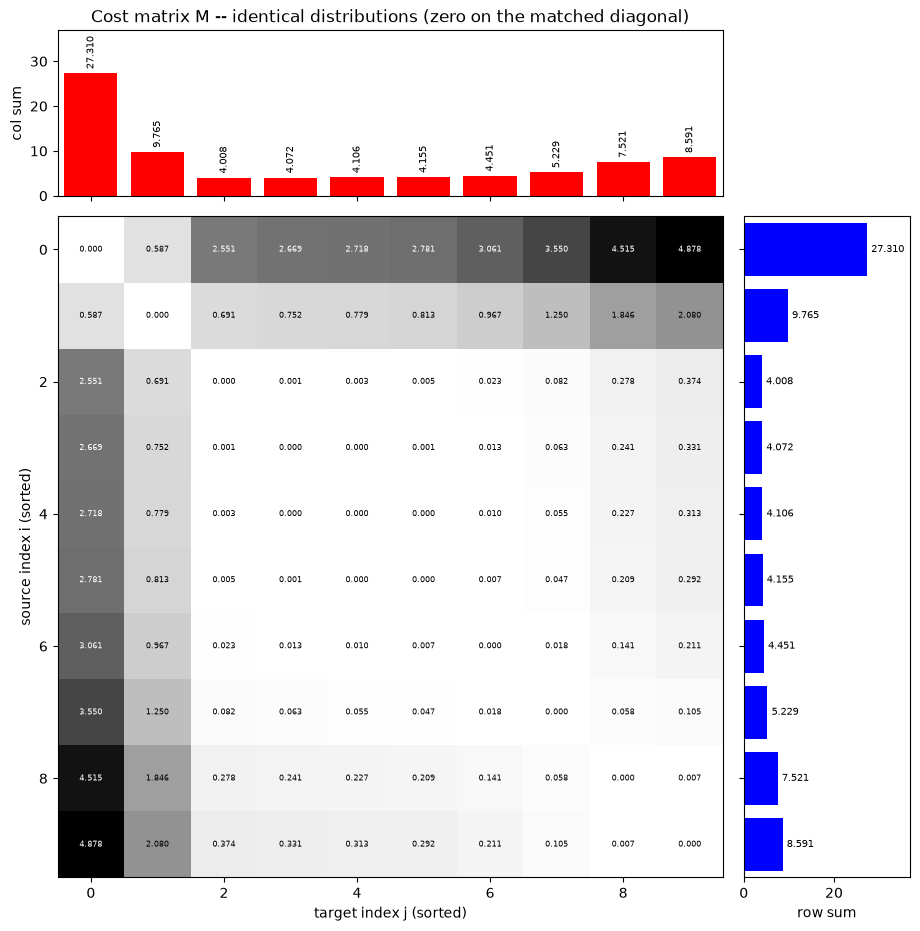

optimal transport cost (identical distributions): 0.000000


In [ ]:


n_extra = 100
rng_extra = np.random.default_rng(1)

x_same = np.sort(rng_extra.normal(0.0, 1.0, n_extra))
y_same = x_same.copy()

G0_same = ot.emd_1d(x_same, y_same)
rows_same, cols_same = np.nonzero(G0_same)
M_same = ot.dist(x_same.reshape(-1, 1), y_same.reshape(-1, 1))

pl.figure(figsize=(7, 4))
y_source, y_target = 0, 1
for i, j in zip(rows_same, cols_same):
    pl.plot([x_same[i], y_same[j]], [y_source, y_target], "k-", alpha=0.5, lw=1, zorder=1)
pl.plot(x_same, np.full_like(x_same, y_source), "+b", label="Source samples", markersize=10, zorder=2)
pl.plot(y_same, np.full_like(y_same, y_target), "xr", label="Target samples", markersize=10, zorder=2)
pl.yticks([y_source, y_target], ["Source", "Target"])
pl.ylim(-0.5, 1.5)
pl.legend(loc="upper left", bbox_to_anchor=(1, 1))
pl.title("Identical distributions: source == target exactly (1D, standard normal)")
pl.tight_layout()

row_sums_same = M_same.sum(axis=1)
col_sums_same = M_same.sum(axis=0)

fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M_same, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j (sorted)")
ax_main.set_ylabel("source index i (sorted)")

# per-cell numeric annotations only when the matrix is small enough to read
if n_extra <= 15:
    vmid = (M_same.max() + M_same.min()) / 2
    for i in range(M_same.shape[0]):
        for j in range(M_same.shape[1]):
            color = "white" if M_same[i, j] > vmid else "black"
            ax_main.text(j, i, f"{M_same[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums_same)), col_sums_same, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M -- identical distributions (zero on the matched diagonal)")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums_same)), row_sums_same, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

print(f"optimal transport cost (identical distributions): {ot.emd2_1d(x_same, y_same) ** 0.5:.6f}")

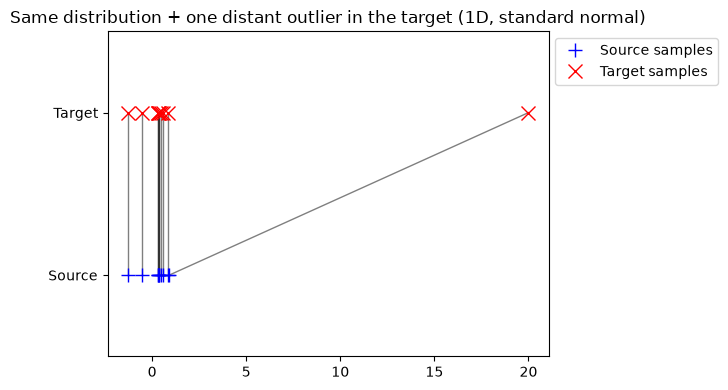

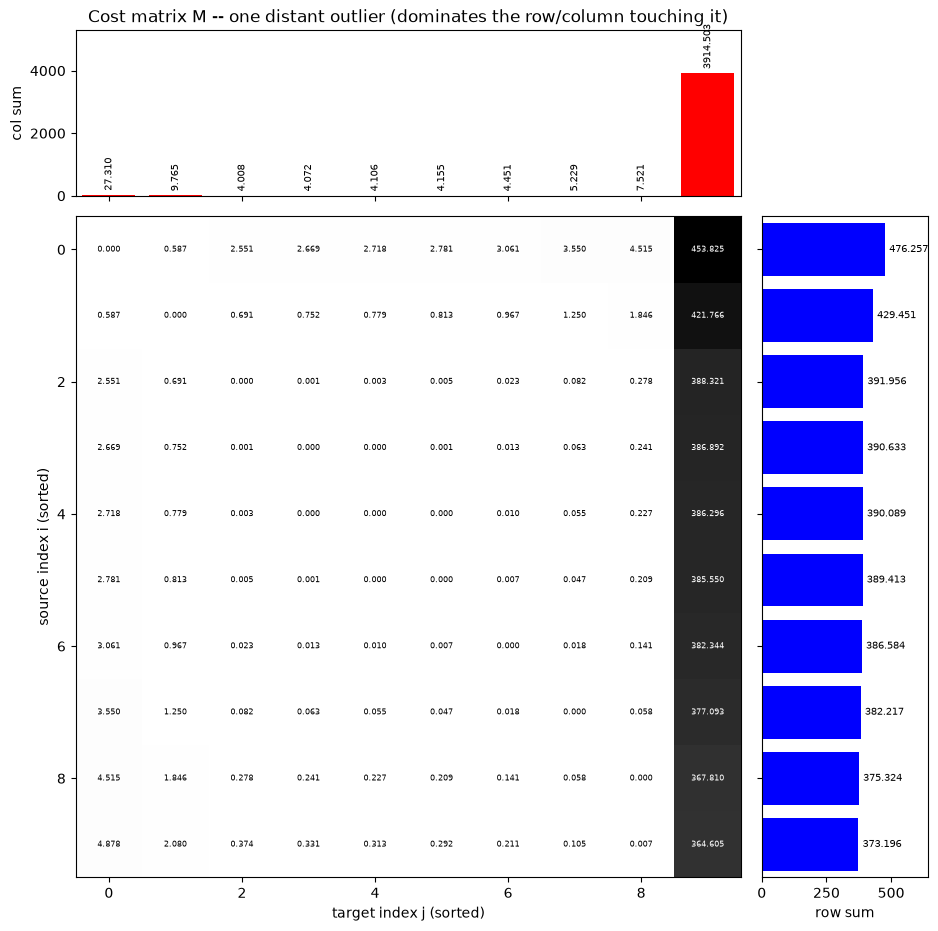

optimal transport cost (one distant outlier): 6.038257
matched pairs with exactly zero cost: 9 out of 10 -- all cost concentrated in 1 pair


In [40]:
# (b) Same as (a), but the target's single LARGEST point is replaced with a
# distant outlier -- every other point still matches exactly (zero cost), so
# the entire optimal transport cost is concentrated in that one matched pair.
# x_same is sorted, so overwriting its current maximum keeps y_out sorted too
# (no re-sort needed) and the matching for every other point is unaffected.

x_out = x_same.copy()
y_out = x_same.copy()
y_out[-1] = 20.0   # distant outlier, replacing what was the largest value

G0_out = ot.emd_1d(x_out, y_out)
rows_out, cols_out = np.nonzero(G0_out)
M_out = ot.dist(x_out.reshape(-1, 1), y_out.reshape(-1, 1))

pl.figure(figsize=(7, 4))
for i, j in zip(rows_out, cols_out):
    pl.plot([x_out[i], y_out[j]], [y_source, y_target], "k-", alpha=0.5, lw=1, zorder=1)
pl.plot(x_out, np.full_like(x_out, y_source), "+b", label="Source samples", markersize=10, zorder=2)
pl.plot(y_out, np.full_like(y_out, y_target), "xr", label="Target samples", markersize=10, zorder=2)
pl.yticks([y_source, y_target], ["Source", "Target"])
pl.ylim(-0.5, 1.5)
pl.legend(loc="upper left", bbox_to_anchor=(1, 1))
pl.title("Same distribution + one distant outlier in the target (1D, standard normal)")
pl.tight_layout()

row_sums_out = M_out.sum(axis=1)
col_sums_out = M_out.sum(axis=0)

fig = pl.figure(figsize=(11, 11))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.imshow(M_out, interpolation="nearest", cmap="gray_r", aspect="auto")
ax_main.set_xlabel("target index j (sorted)")
ax_main.set_ylabel("source index i (sorted)")

# per-cell numeric annotations only when the matrix is small enough to read
if n_extra <= 15:
    vmid = (M_out.max() + M_out.min()) / 2
    for i in range(M_out.shape[0]):
        for j in range(M_out.shape[1]):
            color = "white" if M_out[i, j] > vmid else "black"
            ax_main.text(j, i, f"{M_out[i, j]:.3f}", ha="center", va="center", color=color, fontsize=6)

bars_top = ax_top.bar(np.arange(len(col_sums_out)), col_sums_out, color="red")
ax_top.bar_label(bars_top, fmt="%.3f", fontsize=7, rotation=90, padding=3)
ax_top.set_title("Cost matrix M -- one distant outlier (dominates the row/column touching it)")
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("col sum")
ax_top.margins(y=0.35)

bars_right = ax_right.barh(np.arange(len(row_sums_out)), row_sums_out, color="blue")
ax_right.bar_label(bars_right, fmt="%.3f", fontsize=7, padding=3)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("row sum")
ax_right.margins(x=0.35)
pl.show()

print(f"optimal transport cost (one distant outlier): {ot.emd2_1d(x_out, y_out) ** 0.5:.6f}")
print(f"matched pairs with exactly zero cost: {n_extra - 1} out of {n_extra} -- all cost concentrated in 1 pair")

In [ ]:
alpha = 0.05
rng_pval = np.random.default_rng(2)

tests_extra = [
    (wasserstein_permutation_pvalue, "$W_2$"),
    (mmd_pvalue, "kernel MMD"),
    (hotelling_pvalue, "Hotelling $T^2$"),
]

print("=== Identical distributions (x_same, y_same) ===")
for pvalue_fn, name in tests_extra:
    p = pvalue_fn(x_same, y_same, n_perm=200, rng=rng_pval)
    verdict = "REJECT H0" if p <= alpha else "fail to reject H0"
    print(f"{name:18} p-value = {p:.4f}  ({verdict} at alpha={alpha:g})")

print()
print("=== Same distribution + one distant outlier (x_out, y_out) ===")
for pvalue_fn, name in tests_extra:
    p = pvalue_fn(x_out, y_out, n_perm=200, rng=rng_pval)
    verdict = "REJECT H0" if p <= alpha else "fail to reject H0"
    print(f"{name:18} p-value = {p:.4f}  ({verdict} at alpha={alpha:g})")

=== Identical distributions (x_same, y_same) ===
$W_2$              p-value = 1.0000  (fail to reject H0 at alpha=0.05)
kernel MMD         p-value = 1.0000  (fail to reject H0 at alpha=0.05)
Hotelling $T^2$    p-value = 1.0000  (fail to reject H0 at alpha=0.05)

=== Same distribution + one distant outlier (x_out, y_out) ===
$W_2$              p-value = 1.0000  (fail to reject H0 at alpha=0.05)
kernel MMD         p-value = 0.9552  (fail to reject H0 at alpha=0.05)
Hotelling $T^2$    p-value = 0.6318  (fail to reject H0 at alpha=0.05)


# Null size checks: are all three tests valid?



In [ ]:

from joblib import Parallel, delayed


def null_size_check_ecdf(sample_fn, null_param, n_val, title, tests=None,
                         n_reps=300, n_perm=200, seed=0, n_jobs=6):
    tests = tests or [
        (wasserstein_permutation_pvalue, "$W_2$"),
        (mmd_pvalue, "kernel MMD"),
        (hotelling_pvalue, "Hotelling $T^2$"),
    ]
    child_seeds = np.random.SeedSequence(seed).spawn(n_reps)

    fig, ax = plt.subplots(figsize=(6, 6))
    alphas = np.linspace(0, 1, 200)
    for pvalue_fn, name in tests:
        def _one(cs, fn=pvalue_fn):
            warnings.filterwarnings("ignore", message="The number of replications is low")
            r = np.random.default_rng(cs)
            Xi, Yi = sample_fn(null_param, n_val, r)
            return fn(Xi, Yi, n_perm=n_perm, rng=r)
        pvals = np.array(Parallel(n_jobs=n_jobs)(delayed(_one)(cs) for cs in child_seeds))
        power = [np.mean(pvals <= a) for a in alphas]
        ax.plot(alphas, power, label=name)

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="$y=x$ (valid test)")
    ax.axvline(0.05, color="red", lw=1, label=r"$\alpha = 0.05$")
    ax.set_xlabel(r"significance level $\alpha$")
    ax.set_ylabel(r"$P(\text{p-value} \leq \alpha)$ under $H_0$")
    ax.set_title(title)
    ax.legend()
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

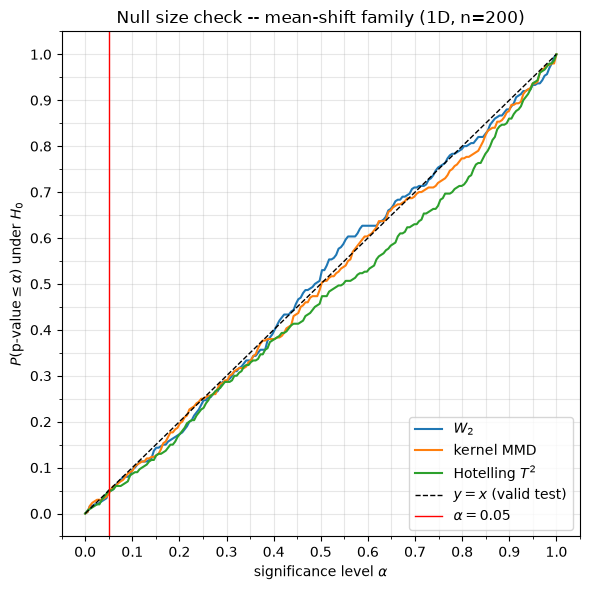

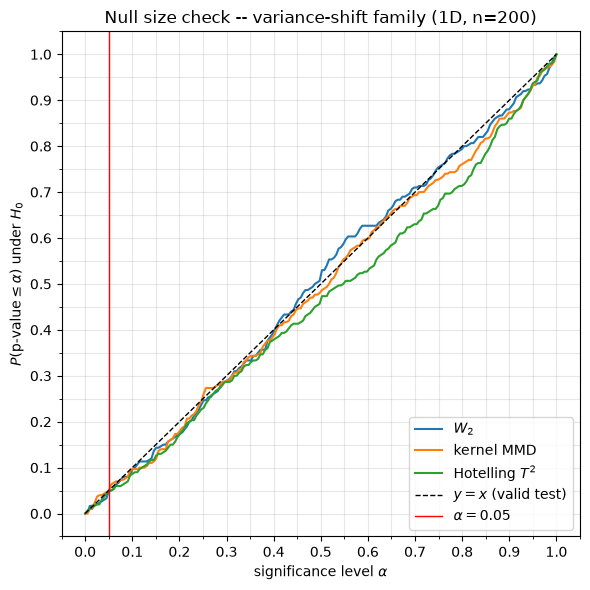

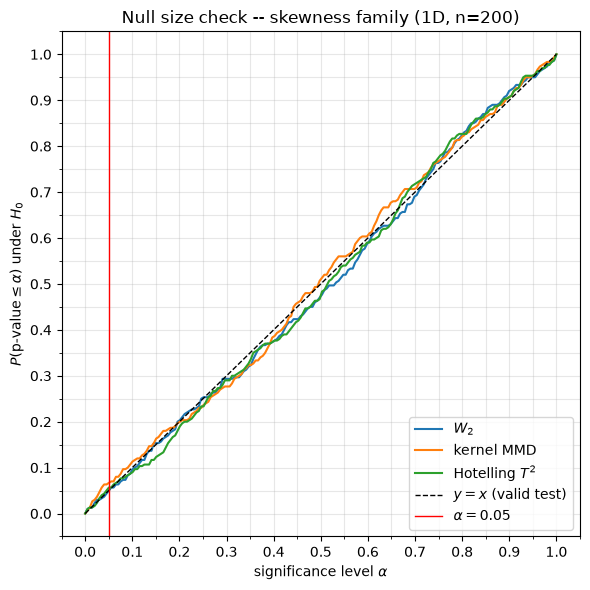

In [47]:
# 1D null size checks -- one family per null parameter (delta=0, std=1, alpha=0)
null_size_check_ecdf(normal_shift_1d, 0.0, 200, "Null size check -- mean-shift family (1D, n=200)")
null_size_check_ecdf(normal_scale_1d, 1.0, 200, "Null size check -- variance-shift family (1D, n=200)")
null_size_check_ecdf(skew_shift_1d, 0.0, 200, "Null size check -- skewness family (1D, n=200)")

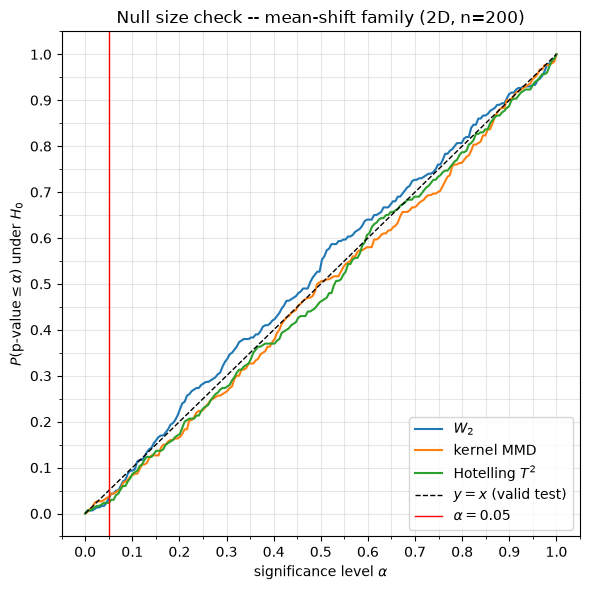

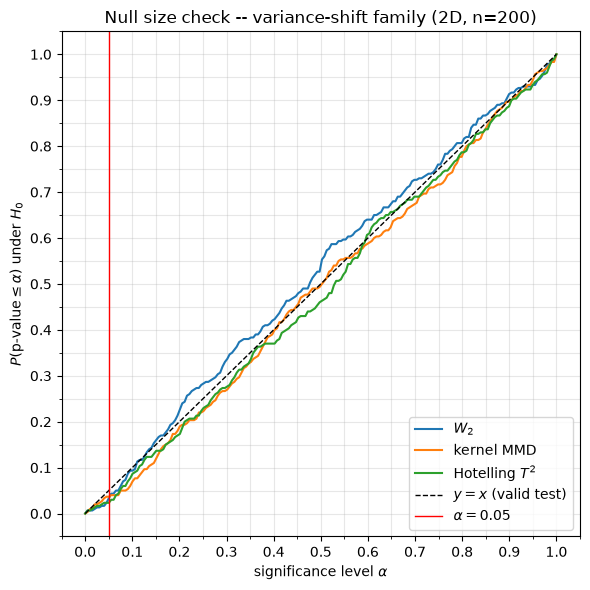

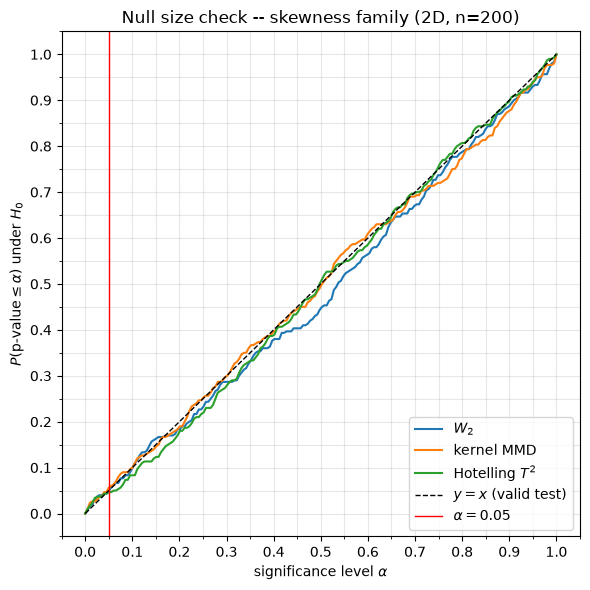

In [48]:
# 2D null size checks
null_size_check_ecdf(normal_shift_2d, 0.0, 200, "Null size check -- mean-shift family (2D, n=200)")
null_size_check_ecdf(normal_scale_2d, 1.0, 200, "Null size check -- variance-shift family (2D, n=200)")
null_size_check_ecdf(skew_shift_2d, 0.0, 200, "Null size check -- skewness family (2D, n=200)")

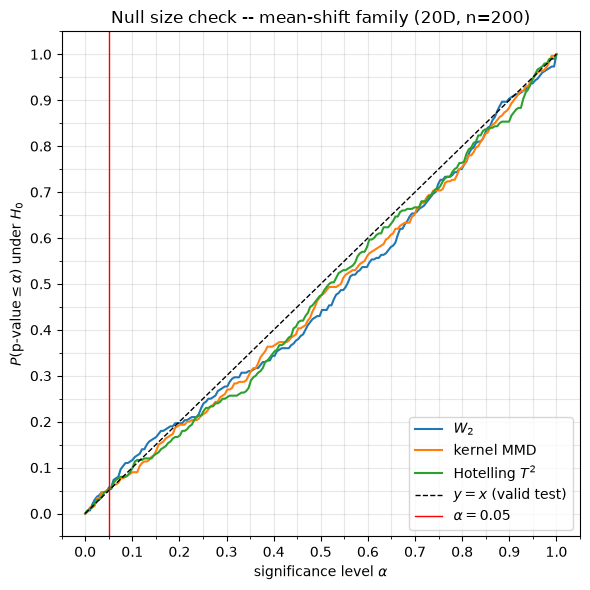

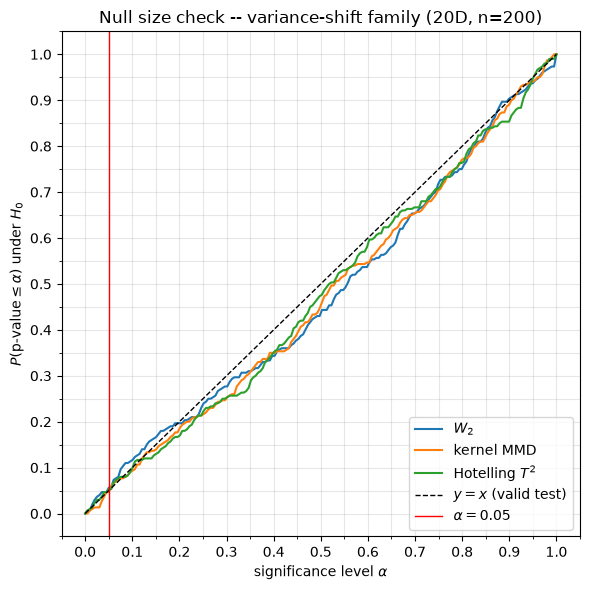

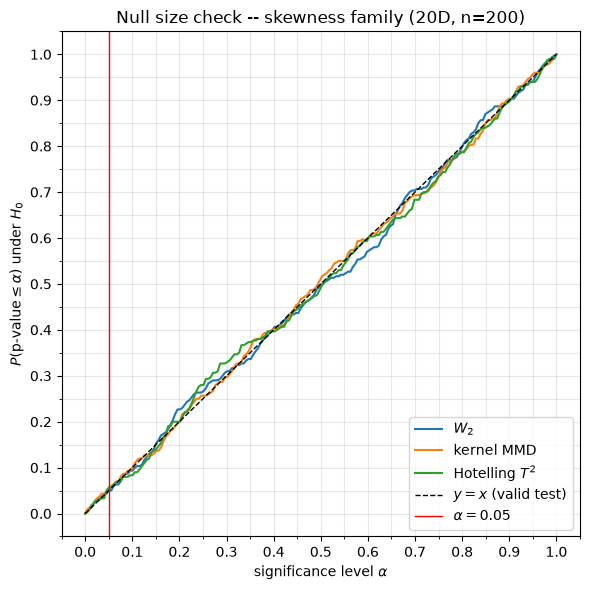

In [49]:
# 20D null size checks
null_size_check_ecdf(normal_shift_20d, 0.0, 200, "Null size check -- mean-shift family (20D, n=200)")
null_size_check_ecdf(normal_scale_20d, 1.0, 200, "Null size check -- variance-shift family (20D, n=200)")
null_size_check_ecdf(skew_shift_20d, 0.0, 200, "Null size check -- skewness family (20D, n=200)")